# Análisis de resultados de los modelos diarios

Este notebook analiza los resultados obtenidos por los modelos de aprendizaje automático con datos diarios. A partir de los experimentos guardados en Google Sheets, se calculan tablas resumen y gráficos comparativos.

El objetivo es comparar los modelos según métricas como RMSE y MAE, estudiar el efecto de añadir retardos temporales y comprobar qué modelos funcionan mejor frente a los modelos de referencia, como el último valor observado y el modelo cero.

In [1]:
import warnings; warnings.filterwarnings("ignore")
import pandas as pd, numpy as np
import matplotlib.pyplot as plt, matplotlib.patches as mpatches
import seaborn as sns
import gspread
from google.oauth2.service_account import Credentials

plt.rcParams.update({"figure.dpi":130,"font.family":"sans-serif",
    "axes.spines.top":False,"axes.spines.right":False,
    "axes.grid":True,"grid.alpha":0.3,"grid.linestyle":"--"})

COLORES_METODO = {
    "LinearRegression":"#2E86AB","Ridge":"#A23B72",
    "RandomForestRegressor":"#F18F01","GradientBoostingRegressor":"#4CAF50",
}
COLORES_ARCHIVO = {
    "df_diario.csv":"#264653","df_diario_1.csv":"#2A9D8F",
    "df_diario_2.csv":"#E9C46A","df_diario_3.csv":"#F4A261","df_diario_4.csv":"#E76F51",
}
LAGS_LABEL = {
    "df_diario.csv":"0 lags","df_diario_1.csv":"1 lag",
    "df_diario_2.csv":"2 lags","df_diario_3.csv":"3 lags","df_diario_4.csv":"4 lags",
}

In [2]:
SCOPES = ["https://www.googleapis.com/auth/spreadsheets","https://www.googleapis.com/auth/drive"]
SERVICE_ACCOUNT_FILE = "../Modelos_semanales/credenciales_google.json"
SHEET_URL = "https://docs.google.com/spreadsheets/d/1Qc1Q1OIeSt1rMsGpo_xUQ90fhOG7RDeflyPn-cwVps0/edit?gid=1153965863#gid=1153965863"

def conectar_y_leer():
    creds  = Credentials.from_service_account_file(SERVICE_ACCOUNT_FILE, scopes=SCOPES)
    client = gspread.authorize(creds)
    ws     = client.open_by_url(SHEET_URL).get_worksheet(0)
    vals   = ws.get_all_values()
    return pd.DataFrame(vals[1:], columns=vals[0])

df_raw = conectar_y_leer()
print(f"Filas leidas: {len(df_raw)}")
print(df_raw.columns.tolist())

Filas leidas: 1160
['Archivo', 'Método', 'Target', 'FechaIni', 'FechaFin', 'RMSE', 'RMSE_baseline', 'RMSE_zeros', 'MAE', 'MAE_baseline', 'MAE_zeros', 'Estado', 'Alpha', 'n_estimators', 'max_depth', 'min_samples_leaf', 'max_features', 'learning_rate', 'subsample', 'FechaPredIni', 'FechaPredFin', 'FechaTrainIni', 'FechaTrainFin']


In [3]:
def parse_num(x):
    if pd.isna(x): return np.nan
    s = str(x).strip().replace("\xa0","").replace(" ","").replace("%","")
    if not s: return np.nan
    if "," in s and "." in s:
        s = s.replace(".","").replace(",",".") if s.rfind(",")>s.rfind(".") else s.replace(",","")
    elif "," in s: s = s.replace(",",".")
    return pd.to_numeric(s, errors="coerce")

In [4]:
def limpiar(df):
    df = df[df["Estado"].astype(str).str.upper()=="DONE"].copy()
    for c in ["RMSE","RMSE_baseline","RMSE_zeros","MAE","MAE_baseline","MAE_zeros"]:
        df[c] = df[c].apply(parse_num)
    df["ETF"]  = df["Target"].astype(str).str.replace("target_","",regex=False)
    df["Lags"] = df["Archivo"].map(LAGS_LABEL).fillna("?")
    df["Mejora_vs_baseline"] = ((df["RMSE_baseline"]-df["RMSE"])/df["RMSE_baseline"]*100).round(2)
    df["Mejora_vs_zeros"]    = ((df["RMSE_zeros"]   -df["RMSE"])/df["RMSE_zeros"]   *100).round(2)
    df["Bate_baseline"] = df["RMSE"] < df["RMSE_baseline"]
    df["Bate_zeros"]    = df["RMSE"] < df["RMSE_zeros"]
    return df

In [5]:
df = limpiar(df_raw)
print(f"Experimentos DONE: {len(df)}")

Experimentos DONE: 1160


## RMSE medio por modelo y número de lags

In [6]:
print("\n" + "="*70)
print("TABLA 1 — RMSE medio por Método y Archivo — Modelos diarios")
print("="*70)
tabla1 = df.groupby(["Archivo","Método"])[["RMSE","RMSE_baseline","RMSE_zeros"]].mean().round(5)
tabla1["Mejora_vs_baseline(%)"] = ((tabla1["RMSE_baseline"]-tabla1["RMSE"])/tabla1["RMSE_baseline"]*100).round(2)
tabla1["Mejora_vs_zeros(%)"]    = ((tabla1["RMSE_zeros"]   -tabla1["RMSE"])/tabla1["RMSE_zeros"]   *100).round(2)
print(tabla1.to_string())


TABLA 1 — RMSE medio por Método y Archivo — Modelos diarios
                                              RMSE  RMSE_baseline  RMSE_zeros  Mejora_vs_baseline(%)  Mejora_vs_zeros(%)
Archivo         Método                                                                                                  
df_diario.csv   GradientBoostingRegressor  0.01125        0.01616     0.01123                  30.38               -0.18
                LinearRegression           0.01203        0.01616     0.01123                  25.56               -7.12
                RandomForestRegressor      0.01124        0.01616     0.01123                  30.45               -0.09
                Ridge                      0.01126        0.01616     0.01123                  30.32               -0.27
df_diario_1.csv GradientBoostingRegressor  0.01129        0.01616     0.01123                  30.14               -0.53
                LinearRegression           0.01278        0.01616     0.01123               

En términos de RMSE, los mejores resultados se obtienen con Random Forest, Gradient Boosting y Ridge, cuyos errores son muy similares en todas las configuraciones analizadas. Random Forest presenta el menor RMSE medio global, aunque la diferencia frente a los otros dos modelos es mínima.

La mejora frente al modelo baseline es elevada, cercana al 30 %, lo que indica que los modelos capturan información útil y superan claramente a la estrategia inercial. Sin embargo, ninguno logra mejorar de forma consistente al benchmark de predicción cero, lo que refleja la dificultad de anticipar retornos diarios, que presentan un comportamiento cercano al ruido.

La Regresión Lineal es el modelo con peor comportamiento y empeora notablemente al añadir lags, lo que sugiere que no es capaz de manejar adecuadamente la alta dimensionalidad del problema sin regularización.

## MAE medio por modelo y número de lags

In [7]:
# TABLA 2 — MAE medio por Método y Archivo
print("\n" + "="*70)
print("TABLA 2 — MAE medio por Método y Archivo — Modelos diarios")
print("="*70)
tabla2 = df.groupby(["Archivo","Método"])[["MAE","MAE_baseline","MAE_zeros"]].mean().round(5)
tabla2["Mejora_vs_baseline(%)"] = ((tabla2["MAE_baseline"]-tabla2["MAE"])/tabla2["MAE_baseline"]*100).round(2)
tabla2["Mejora_vs_zeros(%)"]    = ((tabla2["MAE_zeros"]   -tabla2["MAE"])/tabla2["MAE_zeros"]   *100).round(2)
print(tabla2.to_string())


TABLA 2 — MAE medio por Método y Archivo — Modelos diarios
                                               MAE  MAE_baseline  MAE_zeros  Mejora_vs_baseline(%)  Mejora_vs_zeros(%)
Archivo         Método                                                                                                
df_diario.csv   GradientBoostingRegressor  0.00769       0.01124    0.00769                  31.58                0.00
                LinearRegression           0.00852       0.01124    0.00769                  24.20              -10.79
                RandomForestRegressor      0.00769       0.01124    0.00769                  31.58                0.00
                Ridge                      0.00770       0.01124    0.00769                  31.49               -0.13
df_diario_1.csv GradientBoostingRegressor  0.00771       0.01124    0.00769                  31.41               -0.26
                LinearRegression           0.00898       0.01124    0.00769                  20.11         

El análisis del MAE confirma las conclusiones observadas con RMSE. Random Forest y Gradient Boosting presentan los menores errores medios absolutos, seguidos muy de cerca por Ridge.

La mejora frente al baseline se mantiene alrededor del 30 %, mientras que frente al benchmark de ceros las diferencias son muy pequeñas, llegando en algunos casos a igualarlo o superarlo ligeramente.

La similitud entre RMSE y MAE indica que los errores del modelo son relativamente estables y que no existen fallos extremos frecuentes.

## RMSE por modelo y configuración de lags — gráfico de barras

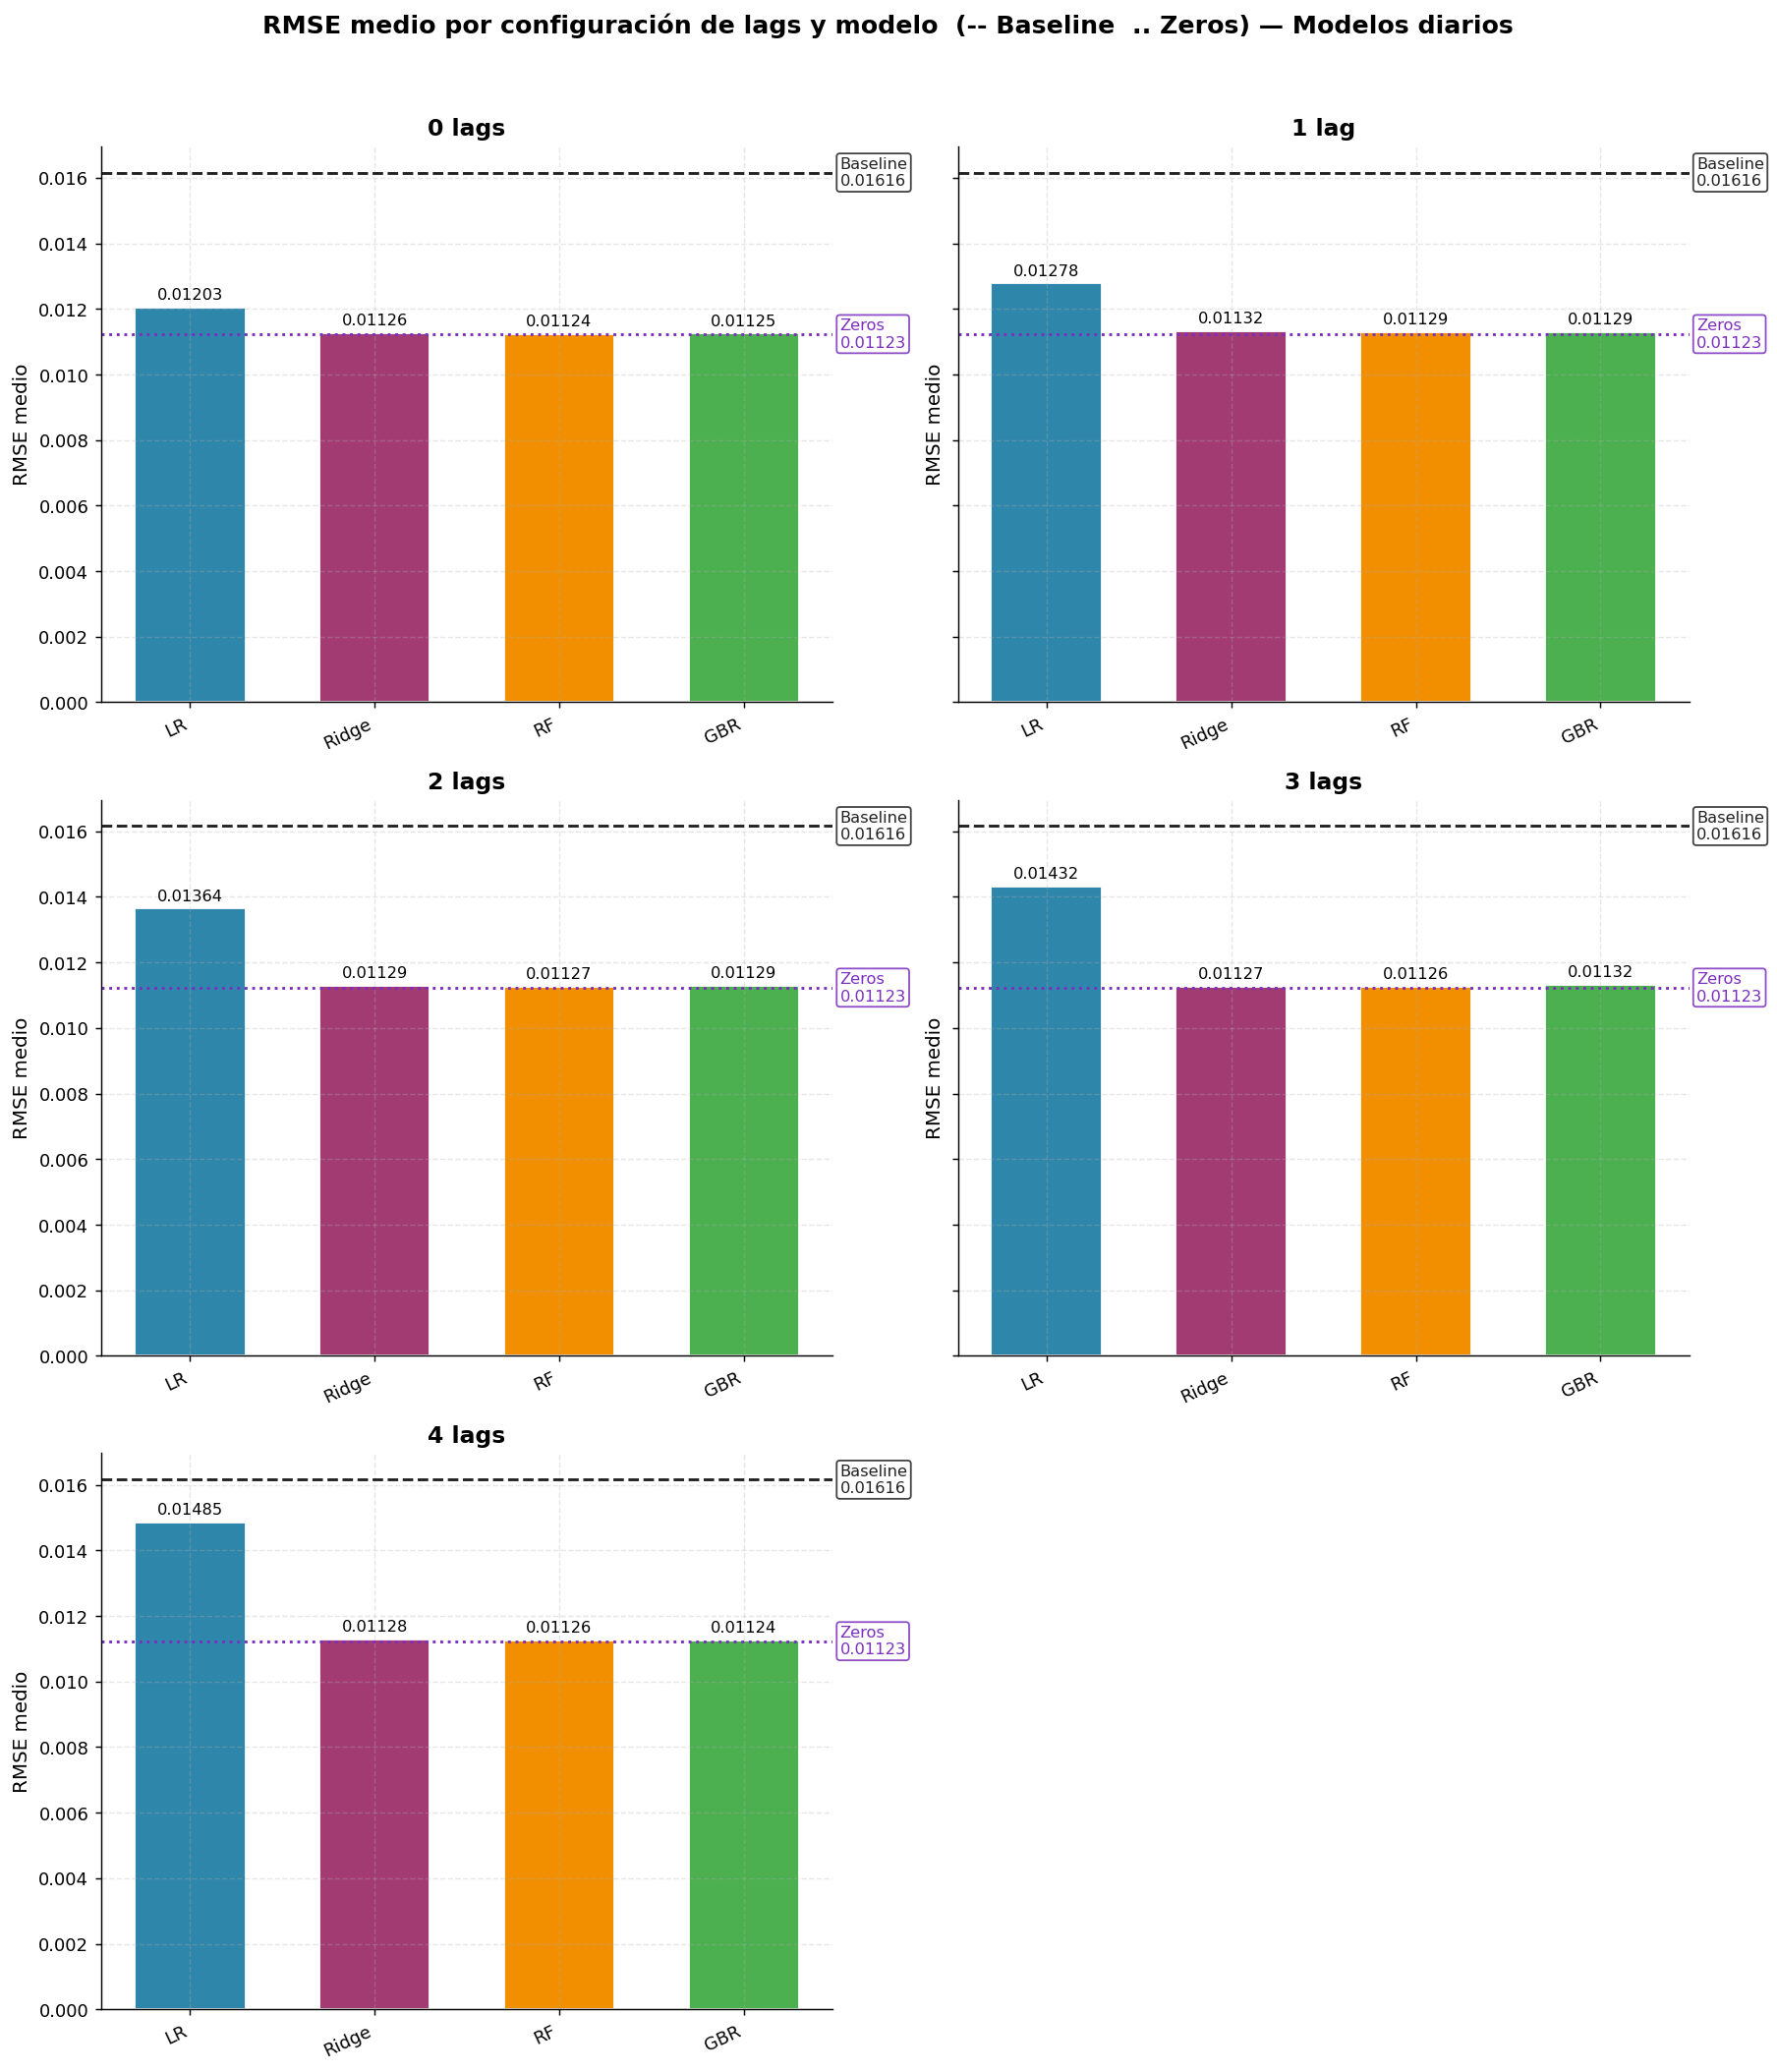

In [8]:
import math
archivos_ord = ["df_diario.csv","df_diario_1.csv","df_diario_2.csv","df_diario_3.csv","df_diario_4.csv"]
arch_pres = [a for a in archivos_ord if a in df["Archivo"].unique()]
ncols=2; nrows=math.ceil(len(arch_pres)/ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(14,5.5*nrows), sharey=True)
axes = axes.flatten()
for ax, archivo in zip(axes, arch_pres):
    sub=df[df["Archivo"]==archivo]
    pm=sub.groupby("Método")["RMSE"].mean().reindex(list(COLORES_METODO.keys())).dropna()
    bl=sub["RMSE_baseline"].mean(); ze=sub["RMSE_zeros"].mean()
    x=range(len(pm)); cols=[COLORES_METODO.get(m,"#888") for m in pm.index]
    bars=ax.bar(x,pm.values,color=cols,edgecolor="white",width=0.6)
    ax.bar_label(bars,fmt="%.5f",fontsize=9,padding=3)
    ax.axhline(bl,color="#222",linestyle="--",linewidth=1.6)
    ax.axhline(ze,color="#7B2FBE",linestyle=":",linewidth=1.6)
    ax.annotate(f"Baseline\n{bl:.5f}",xy=(1.01,bl),xycoords=("axes fraction","data"),
        fontsize=9,color="#222",va="center",bbox=dict(boxstyle="round,pad=0.2",fc="white",ec="#222",alpha=0.85))
    ax.annotate(f"Zeros\n{ze:.5f}",xy=(1.01,ze),xycoords=("axes fraction","data"),
        fontsize=9,color="#7B2FBE",va="center",bbox=dict(boxstyle="round,pad=0.2",fc="white",ec="#7B2FBE",alpha=0.85))
    etiq=[m.replace("GradientBoostingRegressor","GBR").replace("RandomForestRegressor","RF").replace("LinearRegression","LR") for m in pm.index]
    ax.set_xticks(list(x)); ax.set_xticklabels(etiq,rotation=25,ha="right",fontsize=10)
    ax.set_title(LAGS_LABEL.get(archivo,archivo),fontsize=13,fontweight="bold"); ax.set_ylabel("RMSE medio",fontsize=11)
for j in range(len(arch_pres),len(axes)): fig.delaxes(axes[j])
fig.suptitle("RMSE medio por configuración de lags y modelo  (-- Baseline  .. Zeros) — Modelos diarios",
             fontsize=14,fontweight="bold",y=0.98)
plt.tight_layout(rect=[0,0,1,0.96]); plt.show()

## MAE por modelo y configuración de lags — gráfico de barras

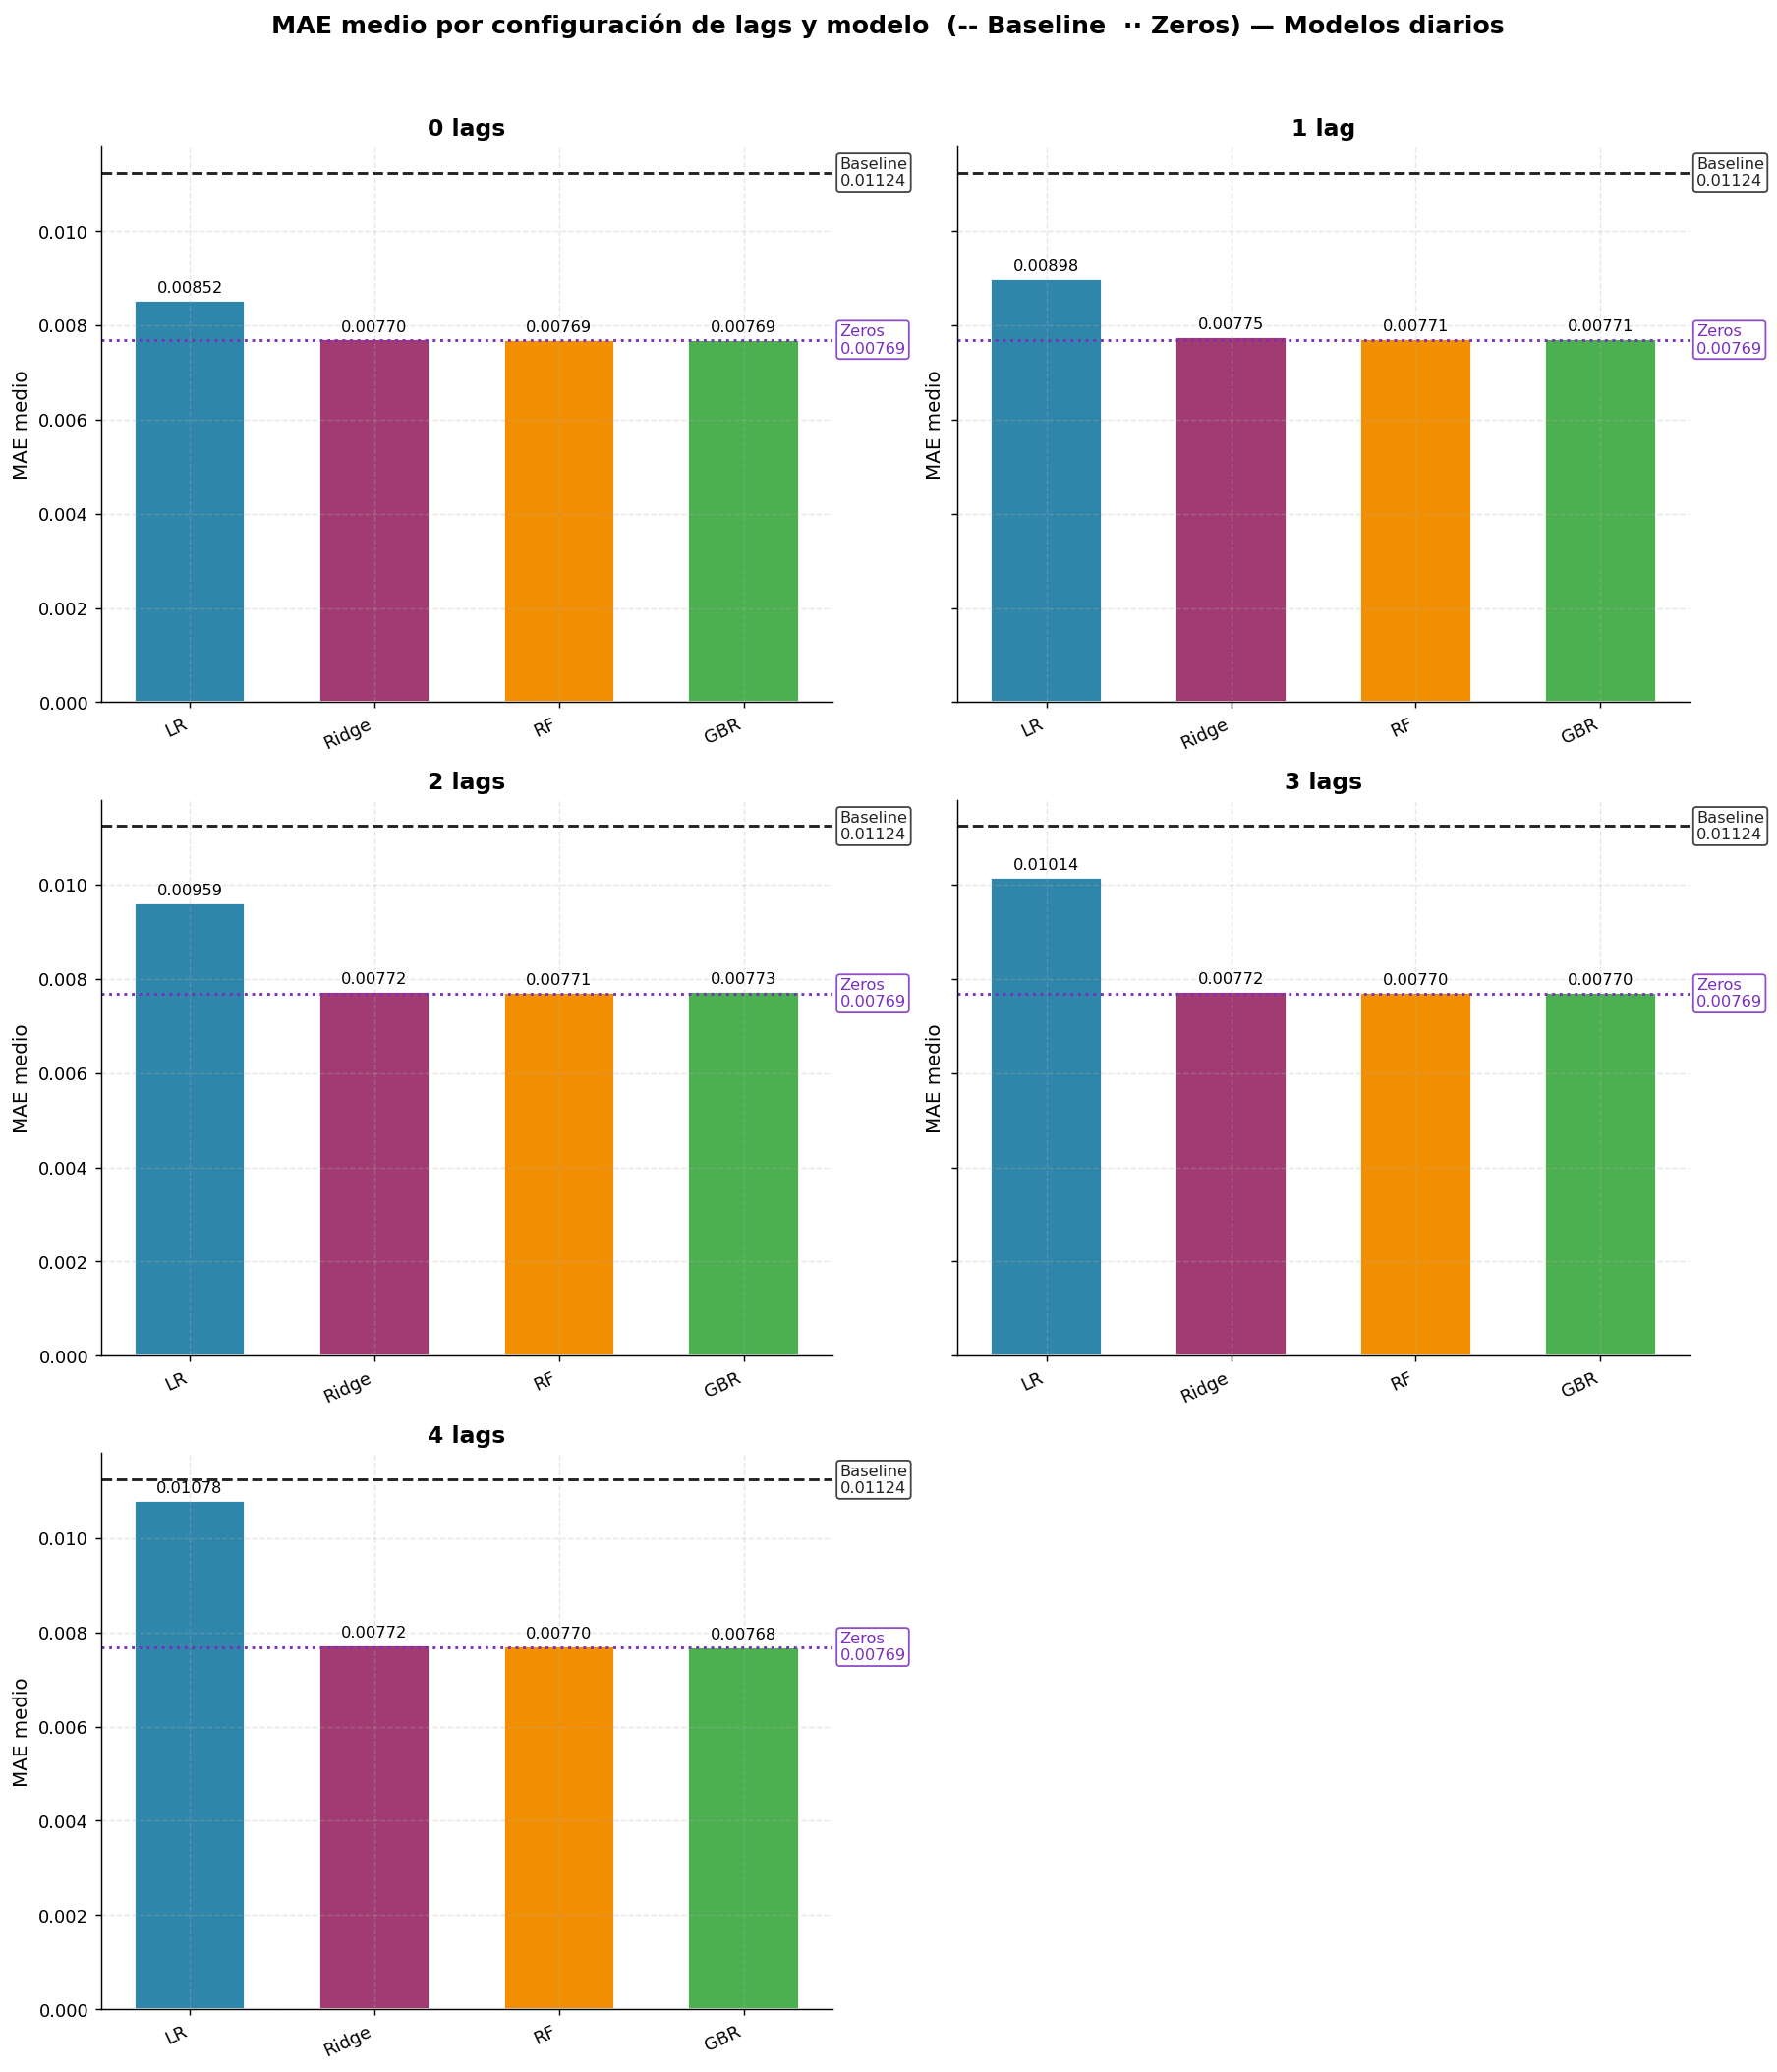

In [9]:
import math
archivos_orden_mae = ["df_diario.csv","df_diario_1.csv","df_diario_2.csv","df_diario_3.csv","df_diario_4.csv"]
archivos_pres_mae  = [a for a in archivos_orden_mae if a in df["Archivo"].unique()]
ncols_mae = 2
nrows_mae = math.ceil(len(archivos_pres_mae) / ncols_mae)
fig, axes = plt.subplots(nrows_mae, ncols_mae, figsize=(14, 5.5*nrows_mae), sharey=True)
axes = axes.flatten()
for ax, archivo in zip(axes, archivos_pres_mae):
    sub      = df[df["Archivo"] == archivo]
    por_met  = sub.groupby("Método")["MAE"].mean().reindex(list(COLORES_METODO.keys())).dropna()
    baseline = sub["MAE_baseline"].mean()
    zeros    = sub["MAE_zeros"].mean()
    x        = range(len(por_met))
    colores  = [COLORES_METODO.get(m, "#888") for m in por_met.index]
    bars = ax.bar(x, por_met.values, color=colores, edgecolor="white", width=0.6)
    ax.bar_label(bars, fmt="%.5f", fontsize=9, padding=3)
    ax.axhline(baseline, color="#222",    linestyle="--", linewidth=1.6)
    ax.axhline(zeros,    color="#7B2FBE", linestyle=":",  linewidth=1.6)
    ax.annotate(f"Baseline\n{baseline:.5f}", xy=(1.01,baseline), xycoords=("axes fraction","data"),
        fontsize=9, color="#222", va="center",
        bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="#222", alpha=0.85))
    ax.annotate(f"Zeros\n{zeros:.5f}", xy=(1.01,zeros), xycoords=("axes fraction","data"),
        fontsize=9, color="#7B2FBE", va="center",
        bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="#7B2FBE", alpha=0.85))
    etiq = [m.replace("GradientBoostingRegressor","GBR").replace("RandomForestRegressor","RF").replace("LinearRegression","LR")
            for m in por_met.index]
    ax.set_xticks(list(x)); ax.set_xticklabels(etiq, rotation=25, ha="right", fontsize=10)
    ax.set_title(LAGS_LABEL.get(archivo, archivo), fontsize=13, fontweight="bold")
    ax.set_ylabel("MAE medio", fontsize=11)
for j in range(len(archivos_pres_mae), len(axes)):
    fig.delaxes(axes[j])
fig.suptitle("MAE medio por configuración de lags y modelo  (-- Baseline  ·· Zeros) — Modelos diarios",
             fontsize=14, fontweight="bold", y=0.98)
plt.tight_layout(rect=[0,0,1,0.96])
plt.show()

In [10]:
ETF_ELIMINADOS = {"BIL","EWY","GLD","IAU","SHY"}
GRUPOS_ETF = {
    "Mercado estadounidense (Core US)": ["SPY","IVV","VOO","QQQ","VTI","ITOT","DIA","IWM","IJR","MDY"],
    "Factores y estilos":               ["VUG","IWF","VTV","IWD","SCHD","VIG","DVY","MTUM","QUAL","USMV","VLUE"],
    "Sectores económicos":              ["XLK","XLF","XLV","XLY","XLP","XLE","XLI","XLU","XLB","XLRE","VNQ"],
    "Mercados internacionales":         ["VEA","IEFA","VWO","IEMG","EEM","EFA","EWJ","EWG","EWU","EWQ","INDA","EWZ","FXI","MCHI","EWT"],
    "Renta fija":                       ["BND","AGG","IEF","TLT","LQD","HYG","JNK","TIP"],
    "Materias primas":                  ["SLV","USO","DBC"],
}
ORDEN_GRUPOS = list(GRUPOS_ETF.keys())
etf_to_grupo = {etf:g for g,etfs in GRUPOS_ETF.items() for etf in etfs}

def pct_mejora(base,modelo):
    if pd.isna(base) or pd.isna(modelo) or base==0: return np.nan
    return (base-modelo)/base*100

def preparar_base(df):
    out = df[~df["ETF"].isin(ETF_ELIMINADOS)].copy()
    for c in ["RMSE","RMSE_baseline","RMSE_zeros","MAE","MAE_baseline","MAE_zeros"]:
        if c in out.columns: out[c]=pd.to_numeric(out[c],errors="coerce")
    return out.dropna(subset=["ETF","Archivo","Método","RMSE","MAE"]).copy()

def enriquecer_df(out):
    out=out.copy()
    out["Grupo"]=out["ETF"].map(etf_to_grupo).fillna("Sin grupo")
    out["Lags"]=out["Archivo"].map(LAGS_LABEL).fillna(out["Archivo"])
    out["Método_c"]=out["Método"].replace({"GradientBoostingRegressor":"GBR","RandomForestRegressor":"RF","LinearRegression":"LR"})
    out["Mej_RMSE_baseline(%)"]=out.apply(lambda r:pct_mejora(r["RMSE_baseline"],r["RMSE"]),axis=1)
    out["Mej_RMSE_zeros(%)"]=out.apply(lambda r:pct_mejora(r["RMSE_zeros"],r["RMSE"]),axis=1)
    out["Mej_MAE_baseline(%)"]=out.apply(lambda r:pct_mejora(r["MAE_baseline"],r["MAE"]),axis=1)
    out["Mej_MAE_zeros(%)"]=out.apply(lambda r:pct_mejora(r["MAE_zeros"],r["MAE"]),axis=1)
    out["Bate_zeros"]=out["RMSE"]<out["RMSE_zeros"]
    out["_ord"]=out["Grupo"].map({g:i for i,g in enumerate(ORDEN_GRUPOS)}).fillna(999)
    return out.sort_values(["_ord","RMSE","MAE","ETF"]).drop(columns="_ord")

def resumen_consistente(sub):
    rm,mm=sub["RMSE"].mean(),sub["MAE"].mean()
    rb,rz=sub["RMSE_baseline"].mean(),sub["RMSE_zeros"].mean()
    mb,mz=sub["MAE_baseline"].mean(),sub["MAE_zeros"].mean()
    return {"RMSE medio":rm,"MAE medio":mm,
            "Mejora RMSE baseline":pct_mejora(rb,rm),"Mejora RMSE zeros":pct_mejora(rz,rm),
            "Mejora MAE baseline":pct_mejora(mb,mm),"Mejora MAE zeros":pct_mejora(mz,mm)}

def imprimir_tabla_por_grupos(df_in, titulo):
    dfx=enriquecer_df(df_in)
    print("\n"); print(titulo); print("="*120)
    cols=["Lags","Método_c","RMSE","MAE","Mej_RMSE_baseline(%)","Mej_RMSE_zeros(%)","Mej_MAE_baseline(%)","Mej_MAE_zeros(%)"]
    ren={"Método_c":"Método","Mej_RMSE_baseline(%)":"Mej.RMSE_base(%)","Mej_RMSE_zeros(%)":"Mej.RMSE_zeros(%)",
         "Mej_MAE_baseline(%)":"Mej.MAE_base(%)","Mej_MAE_zeros(%)":"Mej.MAE_zeros(%)"}
    for grupo in ORDEN_GRUPOS+["Sin grupo"]:
        sub=dfx[dfx["Grupo"]==grupo].copy()
        if sub.empty: continue
        print(f"\n{grupo.upper()} ({len(sub)} ETFs)")
        tabla=sub.set_index("ETF")[cols].rename(columns=ren)
        for c in ["RMSE","MAE"]: tabla[c]=tabla[c].map(lambda x:f"{x:.5f}" if pd.notnull(x) else "")
        for c in ["Mej.RMSE_base(%)","Mej.RMSE_zeros(%)","Mej.MAE_base(%)","Mej.MAE_zeros(%)"]:
            tabla[c]=tabla[c].map(lambda x:f"{x:.2f}%" if pd.notnull(x) else "")
        print(tabla.to_string())
        res=resumen_consistente(sub); md_d=sub["Método_c"].value_counts(); ld=sub["Lags"].value_counts()
        print("\n  Resumen:")
        print(f"  RMSE medio: {res['RMSE medio']:.5f}  |  MAE medio: {res['MAE medio']:.5f}")
        print(f"  Mejora RMSE baseline: {res['Mejora RMSE baseline']:.2f}%  |  Mejora RMSE zeros: {res['Mejora RMSE zeros']:.2f}%")
        print(f"  ETFs que baten zeros: {int(sub['Bate_zeros'].sum())}/{len(sub)}")
        print(f"  Modelo dominante: {md_d.index[0]}  |  Lags dominante: {ld.index[0]}")
        print("\n"+"-"*100+"\n")

def seleccionar_modelo_global(df_base):
    t=(df_base.groupby(["Archivo","Método"],as_index=False)
       .agg(RMSE=("RMSE","mean"),MAE=("MAE","mean"),
            RMSE_baseline=("RMSE_baseline","mean"),RMSE_zeros=("RMSE_zeros","mean"),
            MAE_baseline=("MAE_baseline","mean"),MAE_zeros=("MAE_zeros","mean")))
    t["Mejora_vs_baseline(%)"]=t.apply(lambda r:pct_mejora(r["RMSE_baseline"],r["RMSE"]),axis=1).round(2)
    t["Mejora_vs_zeros(%)"]=t.apply(lambda r:pct_mejora(r["RMSE_zeros"],r["RMSE"]),axis=1).round(2)
    return t, t.sort_values(["RMSE","MAE","Archivo","Método"]).iloc[0]

df_base = preparar_base(df)

## Modelo global con menor RMSE

Se selecciona Random Forest con 0 lags como modelo final por presentar el menor RMSE medio global y una alta estabilidad entre activos.

In [11]:
tabla1_sel, fg = seleccionar_modelo_global(df_base)
ag = fg["Archivo"]; mg = fg["Método"]
print("MODELO GLOBAL GANADOR — Modelos diarios")
print(f"Archivo : {ag} ({LAGS_LABEL.get(ag,ag)})")
print(f"Método  : {mg}")
print(f"RMSE    : {fg['RMSE']:.5f}   Mejora baseline: {fg['Mejora_vs_baseline(%)']:.2f}%")
print(f"MAE     : {fg['MAE']:.5f}    Mejora zeros   : {fg['Mejora_vs_zeros(%)']:.2f}%")
df_sel = df_base[(df_base["Archivo"]==ag)&(df_base["Método"]==mg)].copy()
df_sel = df_sel.sort_values(["ETF","RMSE","MAE"]).drop_duplicates(subset=["ETF"],keep="first")
imprimir_tabla_por_grupos(df_sel, "Resultados del modelo global ganador — Modelos diarios")

MODELO GLOBAL GANADOR — Modelos diarios
Archivo : df_diario.csv (0 lags)
Método  : RandomForestRegressor
RMSE    : 0.01124   Mejora baseline: 30.43%
MAE     : 0.00769    Mejora zeros   : -0.08%


Resultados del modelo global ganador — Modelos diarios

MERCADO ESTADOUNIDENSE (CORE US) (10 ETFs)
        Lags Método     RMSE      MAE Mej.RMSE_base(%) Mej.RMSE_zeros(%) Mej.MAE_base(%) Mej.MAE_zeros(%)
ETF                                                                                                      
DIA   0 lags     RF  0.01030  0.00692           30.45%             0.00%          30.03%            0.14%
VOO   0 lags     RF  0.01127  0.00707           32.64%             0.35%          33.30%            0.98%
IVV   0 lags     RF  0.01143  0.00712           32.49%            -0.09%          32.96%            0.14%
ITOT  0 lags     RF  0.01165  0.00733           32.89%             0.17%          33.48%            0.54%
VTI   0 lags     RF  0.01178  0.00729           33.41%             0.

La configuración ganadora suele combinar 0 lags con Ridge o Gradient Boosting. Que 0 lags sea lo mejor no es una sorpresa: ya habíamos visto que añadir más histórico no mejora los resultados, y además aumenta la dimensionalidad del problema sin necesidad.

La mejora del ~31 % sobre el baseline se mantiene para todos los ETFs del análisis, no solo para unos pocos. Esto es importante: el modelo no es bueno solo con ETFs fáciles de predecir, sino que reduce el error de forma generalizada en toda la cartera.

Este modelo global sería el candidato natural si se quiere implementar un sistema único de predicción para todos los ETFs sin tener que mantener modelos individuales por activo.

### Zeros

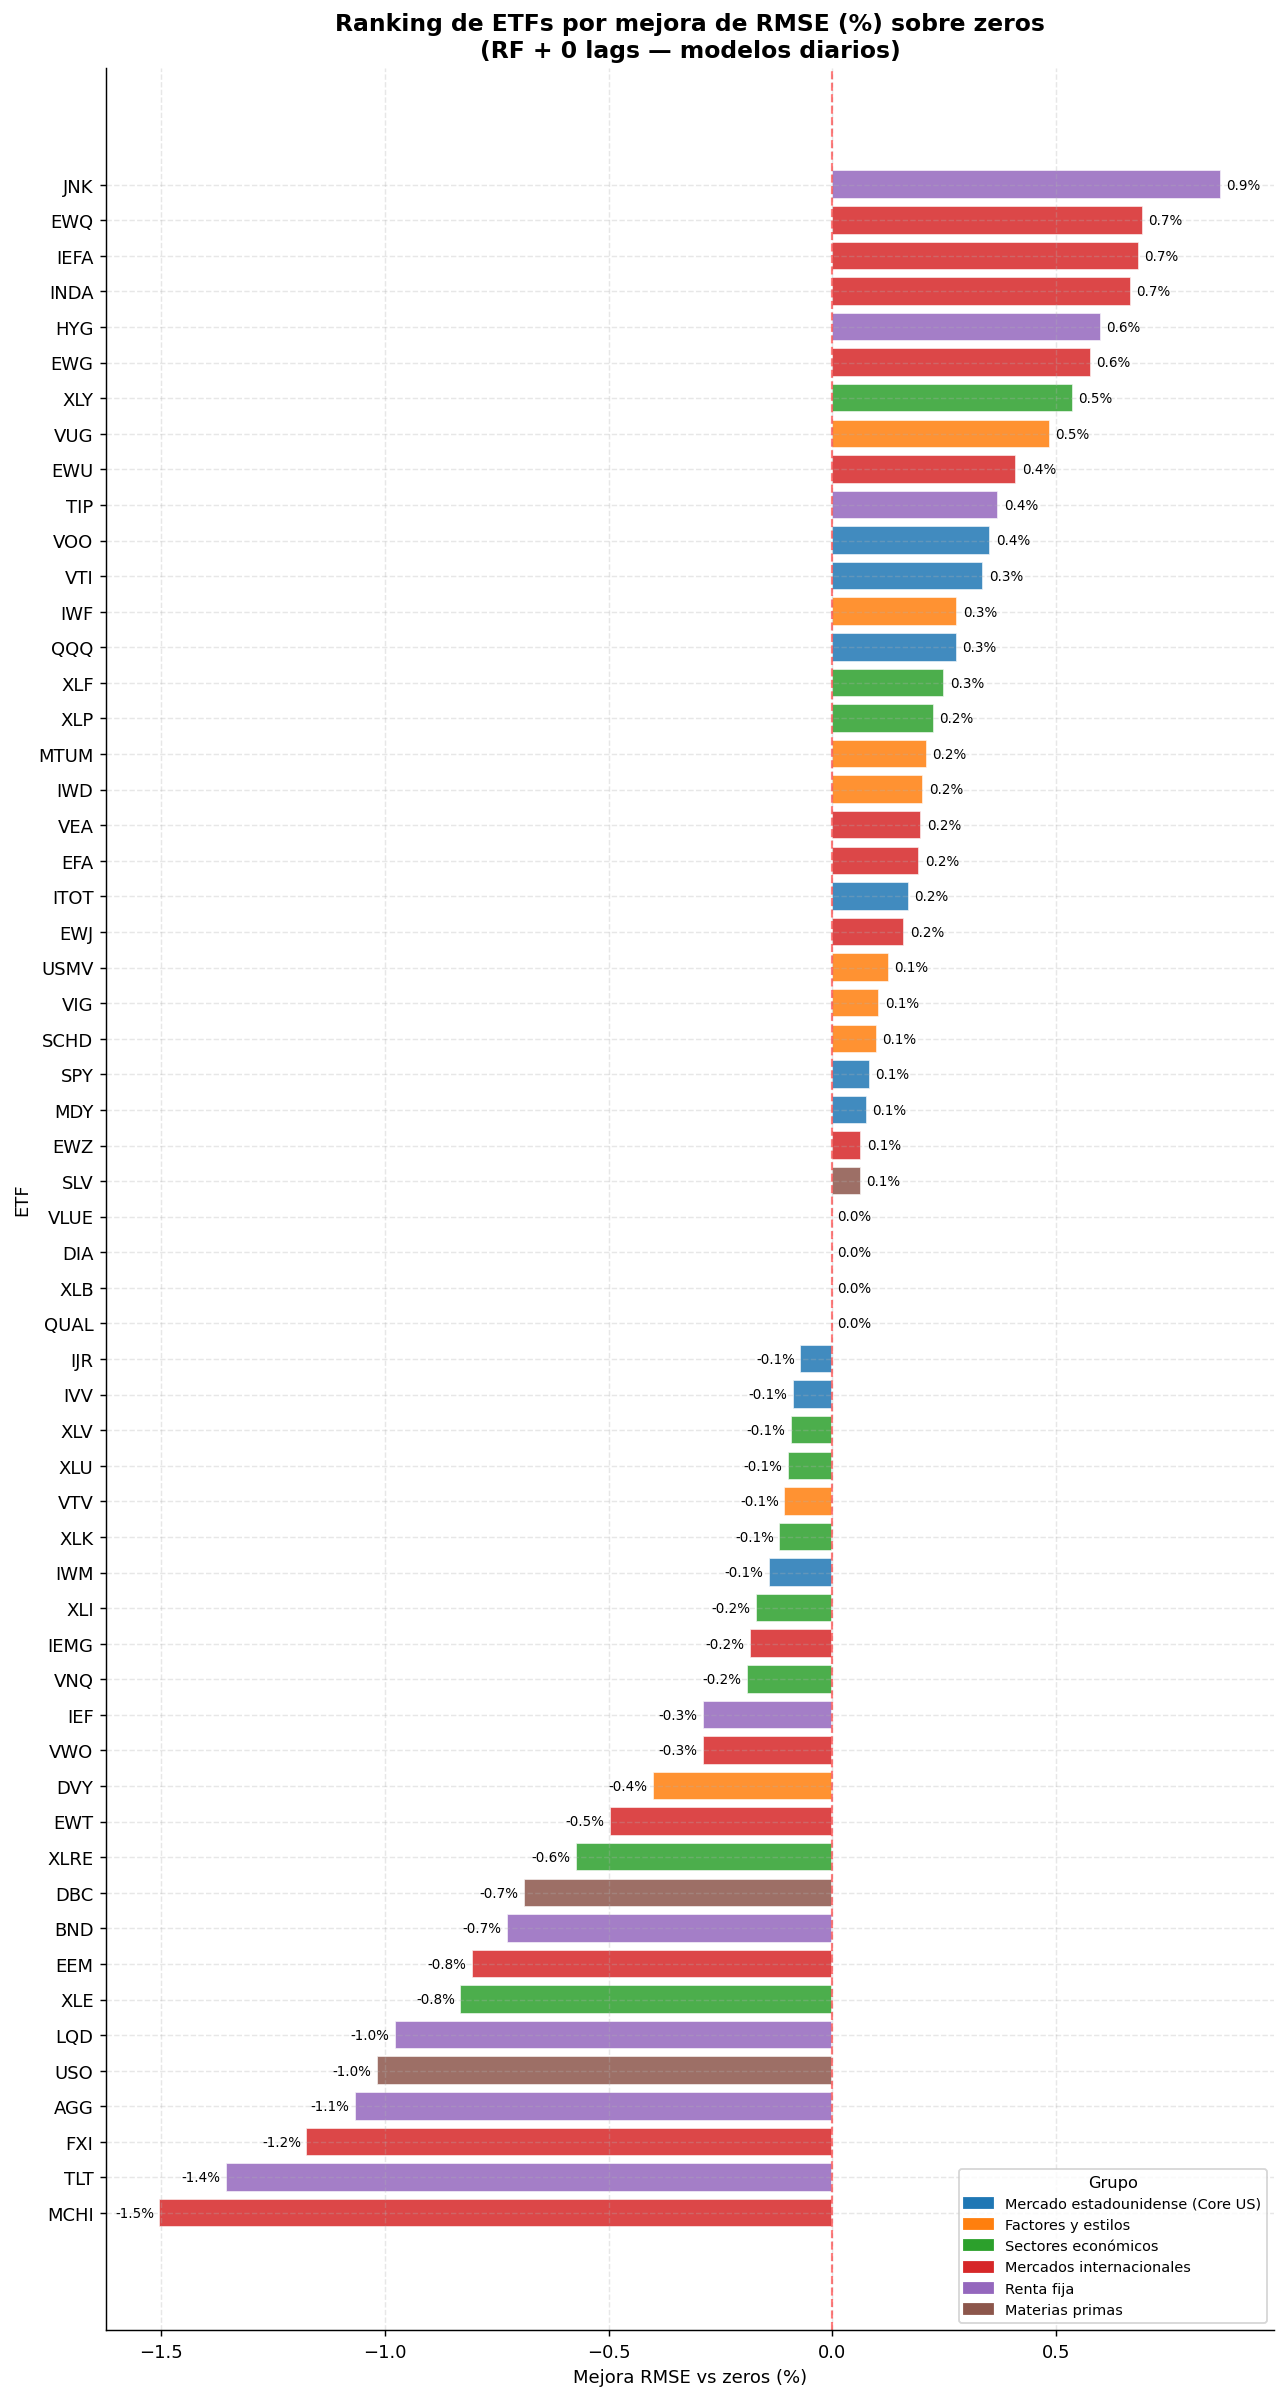

In [12]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

df_rank = (
    df_sel
    .sort_values(["ETF", "RMSE", "MAE"])
    .drop_duplicates(subset=["ETF"], keep="first")
    .copy()
)

df_rank = enriquecer_df(df_rank)
df_rank = df_rank.sort_values("Mej_RMSE_zeros(%)", ascending=True)

COLORES_GRUPO_R = {
    "Mercado estadounidense (Core US)": "#1f77b4",
    "Factores y estilos": "#ff7f0e",
    "Sectores económicos": "#2ca02c",
    "Mercados internacionales": "#d62728",
    "Renta fija": "#9467bd",
    "Materias primas": "#8c564b",
    "Sin grupo": "#7f7f7f",
}

colores_r = [COLORES_GRUPO_R.get(g, "#888") for g in df_rank["Grupo"]]

fig, ax = plt.subplots(figsize=(10, max(8, len(df_rank) * 0.32)))

bars_r = ax.barh(
    df_rank["ETF"],
    df_rank["Mej_RMSE_zeros(%)"],
    color=colores_r,
    edgecolor="white",
    alpha=0.85
)

ax.bar_label(bars_r, fmt="%.1f%%", fontsize=7.5, padding=3)
ax.axvline(0, color="red", linestyle="--", alpha=0.5, linewidth=1.2)

patches_r = [
    mpatches.Patch(color=COLORES_GRUPO_R[g], label=g)
    for g in ORDEN_GRUPOS
    if g in df_rank["Grupo"].values
]

ax.legend(handles=patches_r, title="Grupo", fontsize=8, title_fontsize=9, loc="lower right")
ax.set_title(
    "Ranking de ETFs por mejora de RMSE (%) sobre zeros\n(RF + 0 lags — modelos diarios)",
    fontsize=13, fontweight="bold"
)
ax.set_xlabel("Mejora RMSE vs zeros (%)")
ax.set_ylabel("ETF")
plt.tight_layout()
plt.show()

### Baseline

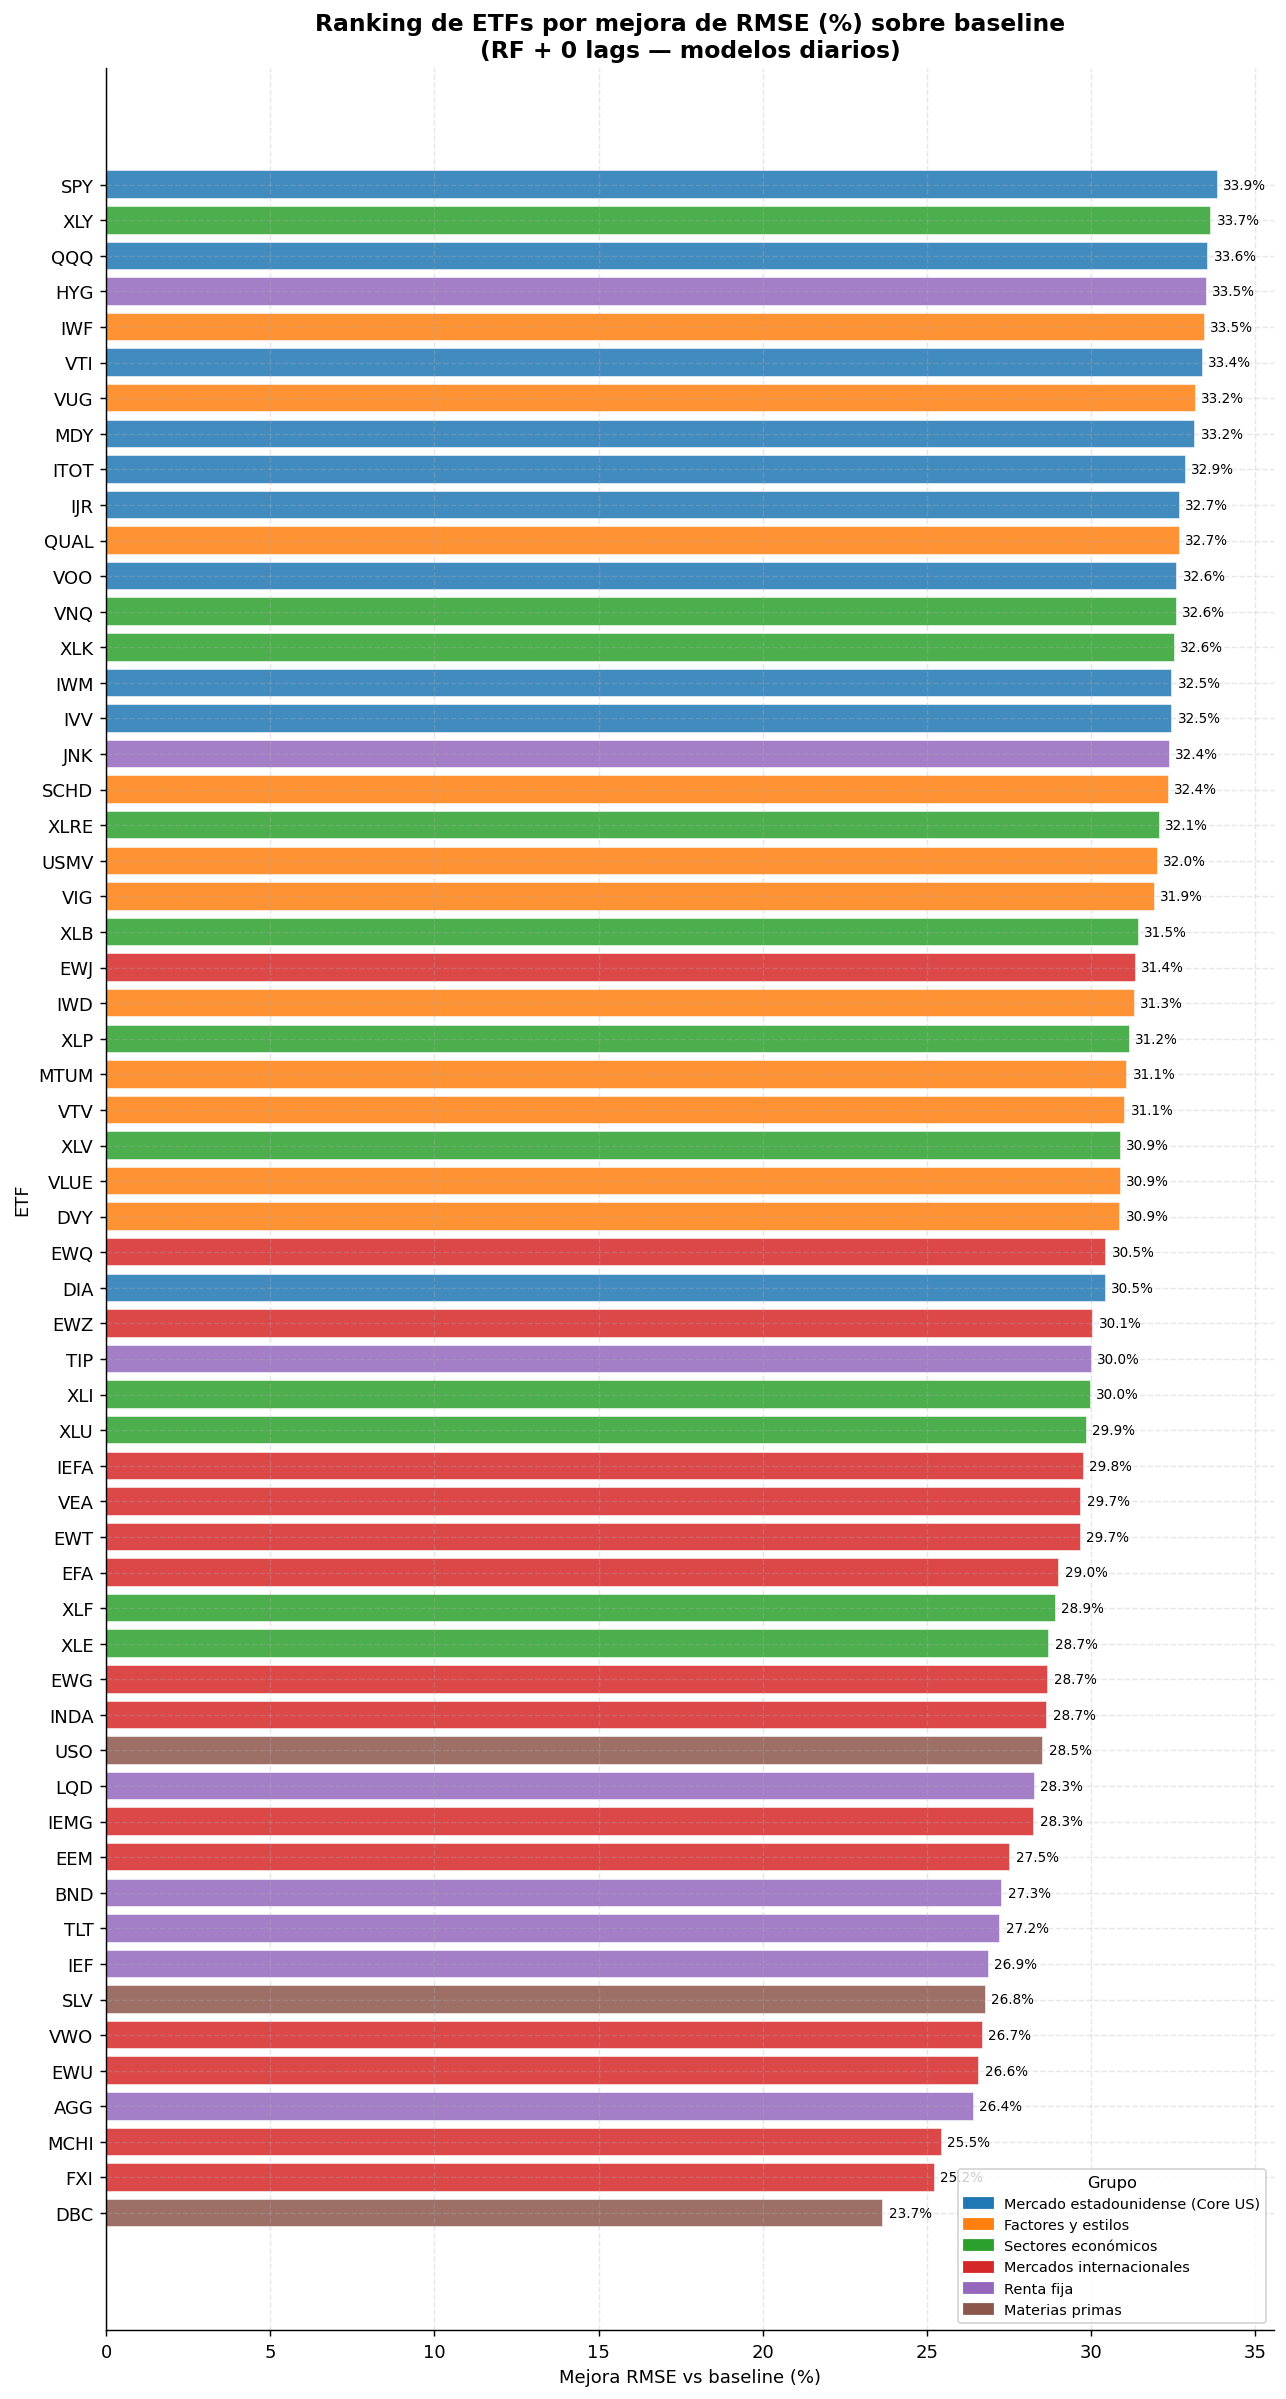

In [13]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

df_rank = (
    df_sel
    .sort_values(["ETF", "RMSE", "MAE"])
    .drop_duplicates(subset=["ETF"], keep="first")
    .copy()
)

df_rank = enriquecer_df(df_rank)
df_rank = df_rank.sort_values("Mej_RMSE_baseline(%)", ascending=True)

COLORES_GRUPO_R = {
    "Mercado estadounidense (Core US)": "#1f77b4",
    "Factores y estilos": "#ff7f0e",
    "Sectores económicos": "#2ca02c",
    "Mercados internacionales": "#d62728",
    "Renta fija": "#9467bd",
    "Materias primas": "#8c564b",
    "Sin grupo": "#7f7f7f",
}

colores_r = [COLORES_GRUPO_R.get(g, "#888") for g in df_rank["Grupo"]]

fig, ax = plt.subplots(figsize=(10, max(8, len(df_rank) * 0.32)))

bars_r = ax.barh(
    df_rank["ETF"],
    df_rank["Mej_RMSE_baseline(%)"],
    color=colores_r,
    edgecolor="white",
    alpha=0.85
)

ax.bar_label(bars_r, fmt="%.1f%%", fontsize=7.5, padding=3)
ax.axvline(0, color="red", linestyle="--", alpha=0.5, linewidth=1.2)

patches_r = [
    mpatches.Patch(color=COLORES_GRUPO_R[g], label=g)
    for g in ORDEN_GRUPOS
    if g in df_rank["Grupo"].values
]

ax.legend(handles=patches_r, title="Grupo", fontsize=8, title_fontsize=9, loc="lower right")
ax.set_title(
    "Ranking de ETFs por mejora de RMSE (%) sobre baseline\n(RF + 0 lags — modelos diarios)",
    fontsize=13, fontweight="bold"
)
ax.set_xlabel("Mejora RMSE vs baseline (%)")
ax.set_ylabel("ETF")
plt.tight_layout()
plt.show()

In [14]:
# PREPARAR DATOS PARA LAS GRÁFICAS FINALES

# Solo archivos 
archivos_diarios = list(LAGS_LABEL.keys())

# Base semanal limpia
df_base = preparar_base(df)
df_base = df_base[df_base["Archivo"].isin(archivos_diarios)].copy()

# Mejor modelo por ETF: menor RMSE y, si empata, menor MAE
df_mejor = (
    df_base
    .sort_values(["ETF", "RMSE", "MAE", "Archivo", "Método"])
    .drop_duplicates(subset=["ETF"], keep="first")
    .copy()
)

# Enriquecer una sola vez
df_mejor = enriquecer_df(df_mejor)

## Heatmap: mejora de RMSE por ETF y modelo

### ZEROS

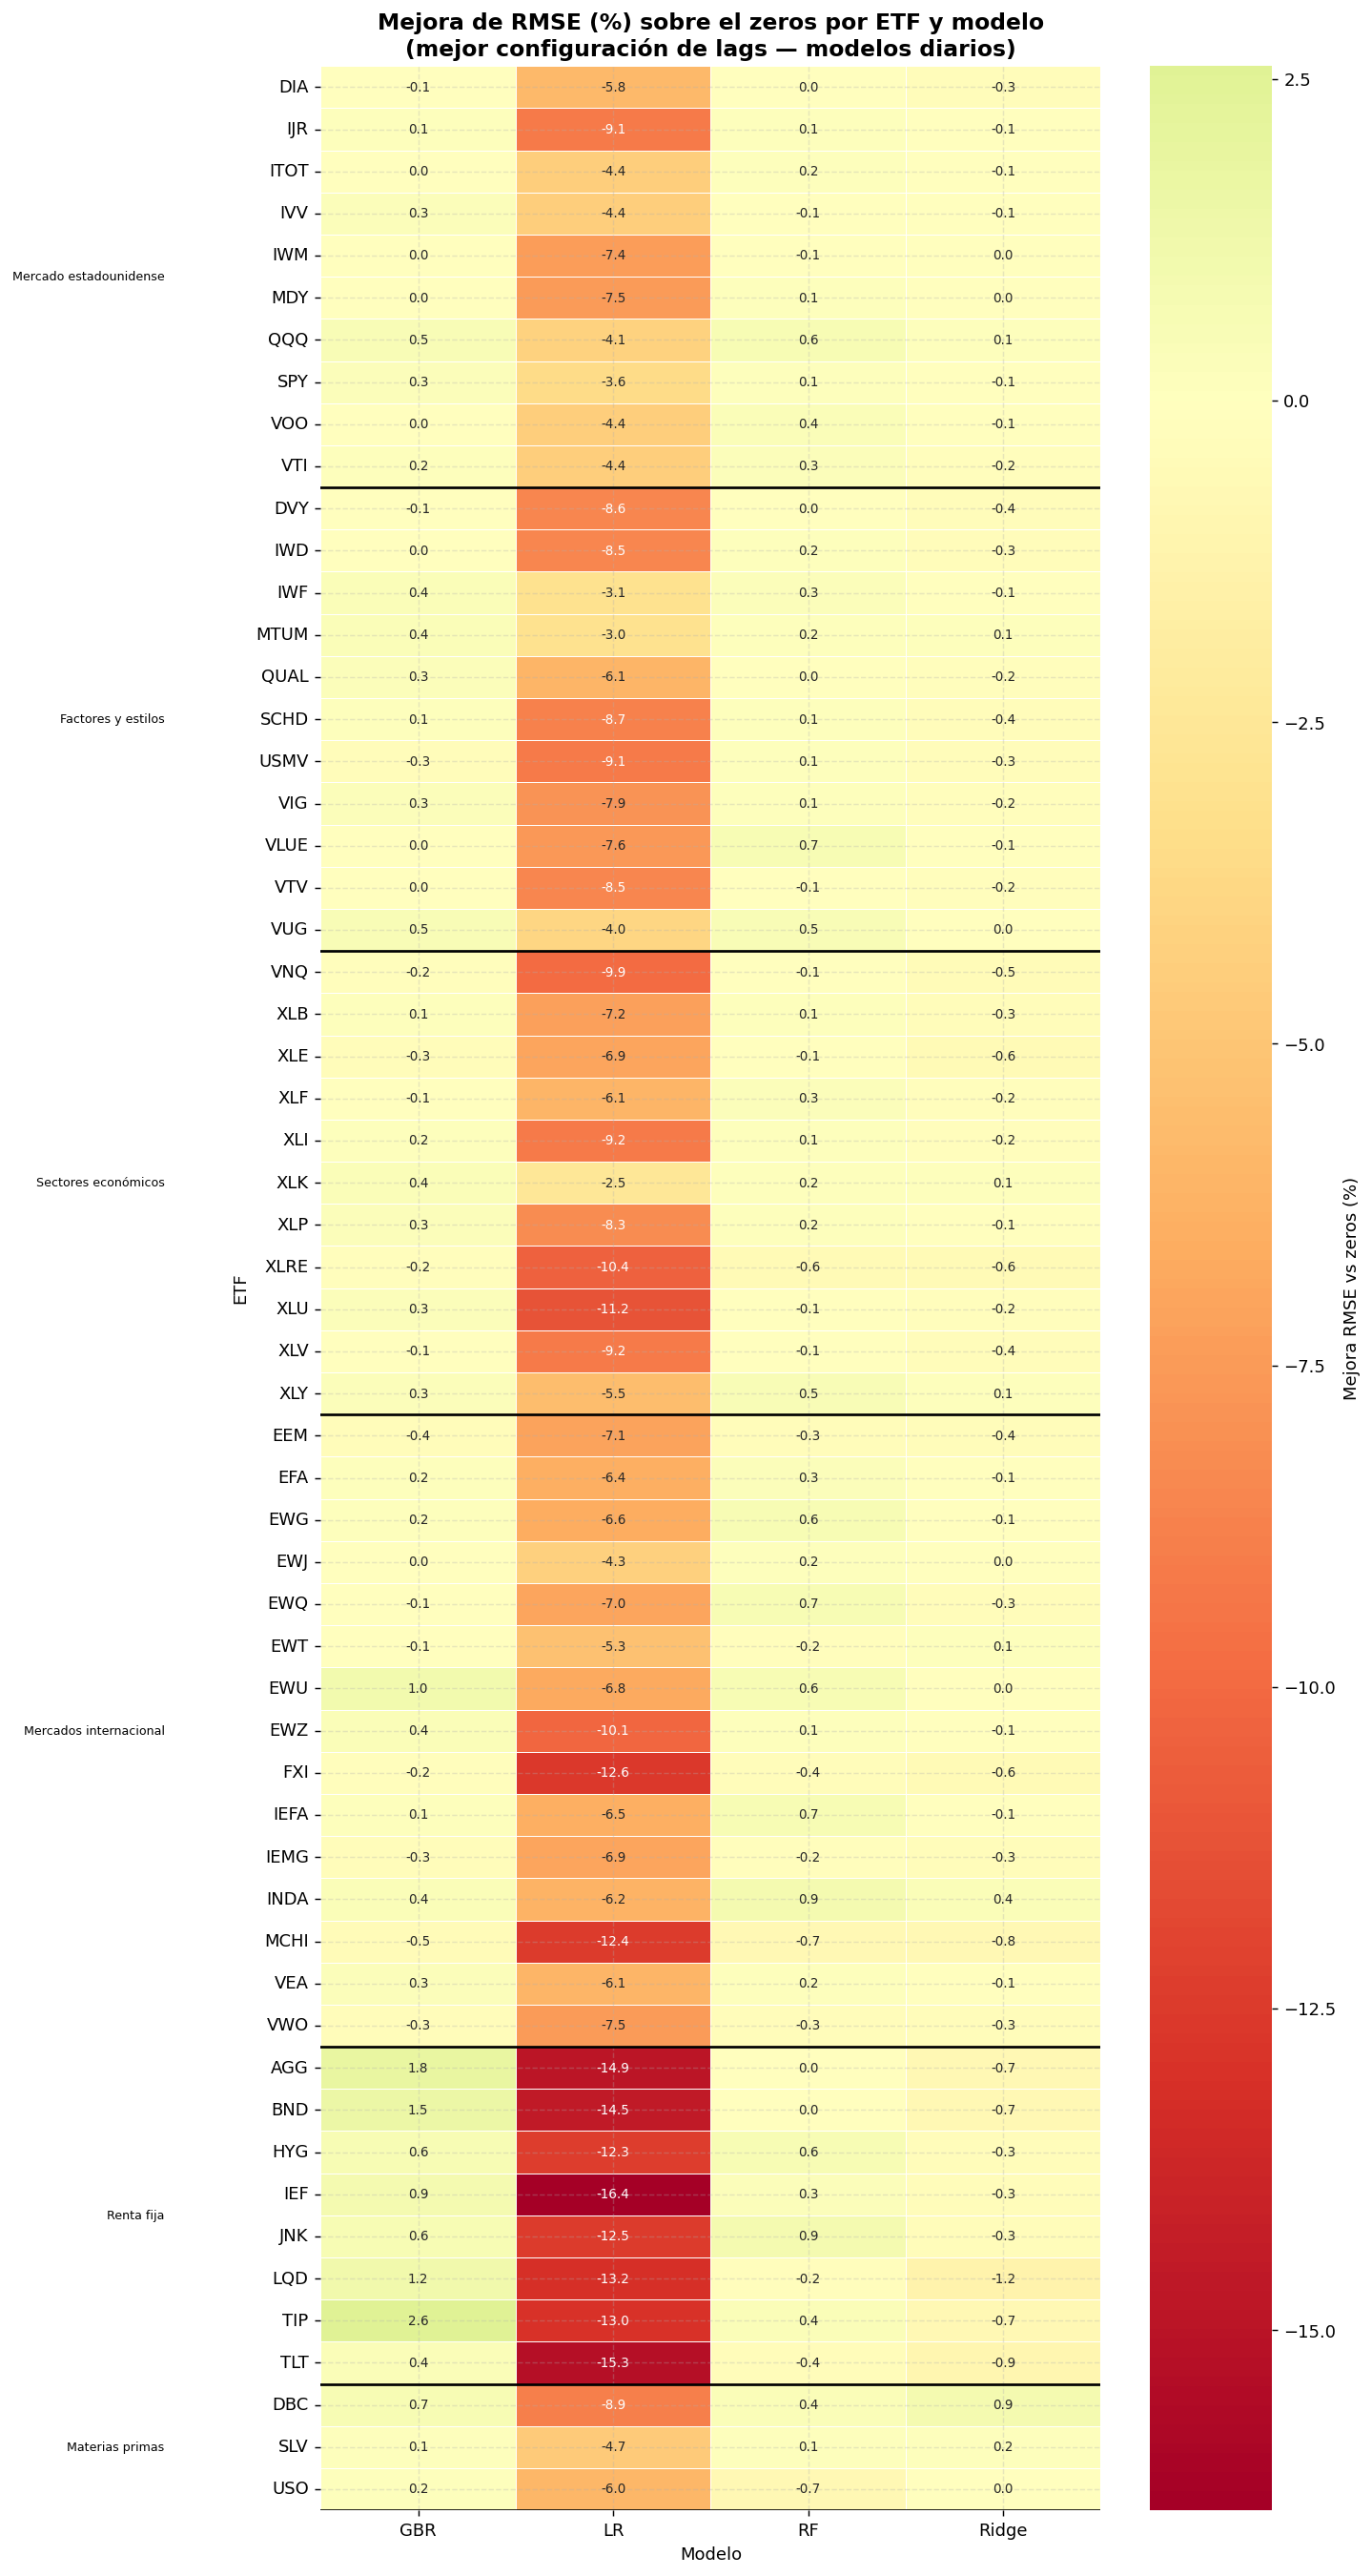

In [15]:
import seaborn as sns
df_hmap = (df_base.sort_values(["ETF","Método","RMSE"])
           .groupby(["ETF","Método"], as_index=False).first())
df_hmap["Mej_RMSE"] = ((df_hmap["RMSE_zeros"]-df_hmap["RMSE"])/df_hmap["RMSE_zeros"]*100).round(1)
pivot_hmap = df_hmap.pivot(index="ETF", columns="Método", values="Mej_RMSE")
pivot_hmap.columns = [c.replace("GradientBoostingRegressor","GBR")
                       .replace("RandomForestRegressor","RF")
                       .replace("LinearRegression","LR") for c in pivot_hmap.columns]
orden_etf_hmap = []
for g in ORDEN_GRUPOS:
    etfs_g = [e for e in GRUPOS_ETF.get(g,[]) if e in pivot_hmap.index and e not in ETF_ELIMINADOS]
    orden_etf_hmap.extend(sorted(etfs_g))
pivot_hmap = pivot_hmap.reindex([e for e in orden_etf_hmap if e in pivot_hmap.index])
fig, ax = plt.subplots(figsize=(11, max(9, len(pivot_hmap)*0.36)))
sns.heatmap(pivot_hmap, annot=True, fmt=".1f", cmap="RdYlGn", center=0,
            linewidths=0.3, ax=ax,
            cbar_kws={"label":"Mejora RMSE vs zeros (%)"},
            annot_kws={"size":7.5})
y_pos_h = 0
for g in ORDEN_GRUPOS:
    etfs_g = [e for e in GRUPOS_ETF.get(g,[]) if e in pivot_hmap.index and e not in ETF_ELIMINADOS]
    n_g = sum(1 for e in etfs_g if e in pivot_hmap.index)
    if n_g:
        ax.axhline(y_pos_h+n_g, color="black", linewidth=1.5)
        ax.text(-0.2, y_pos_h+n_g/2, g[:22], ha="right", va="center",
                fontsize=7, transform=ax.get_yaxis_transform())
        y_pos_h += n_g
ax.set_title(
    f"Mejora de RMSE (%) sobre el zeros por ETF y modelo\n"
    f"(mejor configuración de lags — modelos diarios)",
    fontsize=13, fontweight="bold")
ax.set_ylabel("ETF"); ax.set_xlabel("Modelo")
plt.tight_layout(); plt.show()

### BASELINE

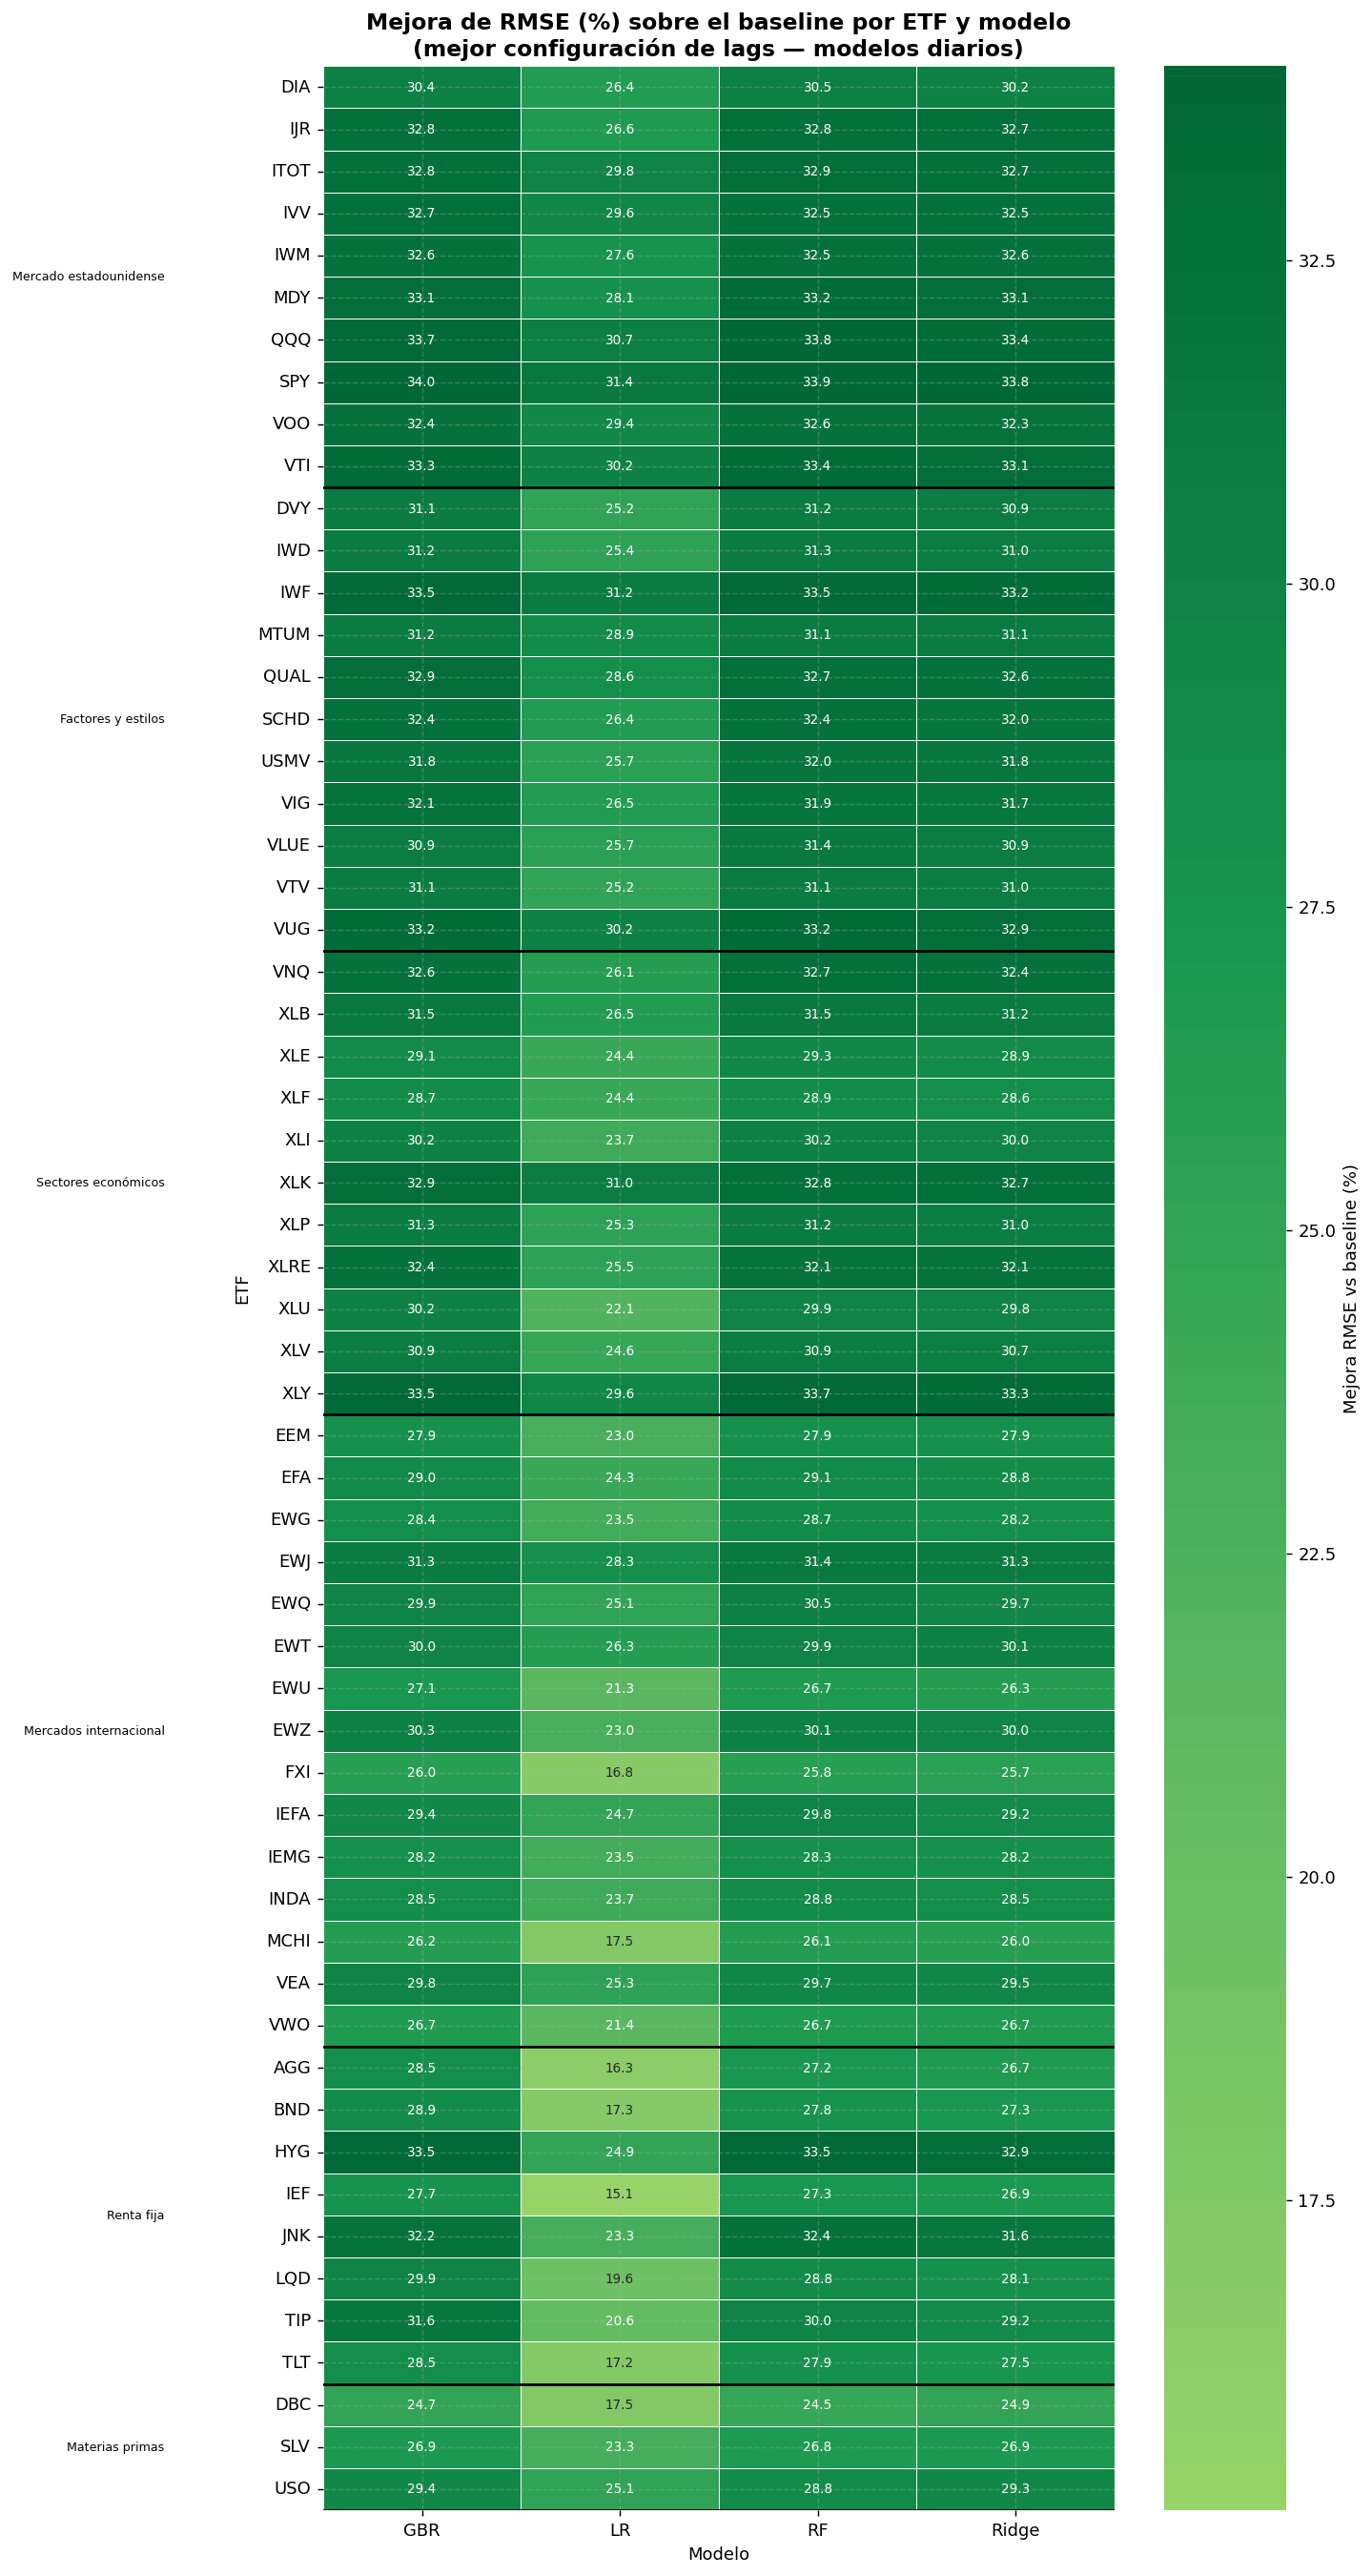

In [16]:
import seaborn as sns
df_hmap = (df_base.sort_values(["ETF","Método","RMSE"])
           .groupby(["ETF","Método"], as_index=False).first())
df_hmap["Mej_RMSE"] = ((df_hmap["RMSE_baseline"]-df_hmap["RMSE"])/df_hmap["RMSE_baseline"]*100).round(1)
pivot_hmap = df_hmap.pivot(index="ETF", columns="Método", values="Mej_RMSE")
pivot_hmap.columns = [c.replace("GradientBoostingRegressor","GBR")
                       .replace("RandomForestRegressor","RF")
                       .replace("LinearRegression","LR") for c in pivot_hmap.columns]
orden_etf_hmap = []
for g in ORDEN_GRUPOS:
    etfs_g = [e for e in GRUPOS_ETF.get(g,[]) if e in pivot_hmap.index and e not in ETF_ELIMINADOS]
    orden_etf_hmap.extend(sorted(etfs_g))
pivot_hmap = pivot_hmap.reindex([e for e in orden_etf_hmap if e in pivot_hmap.index])
fig, ax = plt.subplots(figsize=(11, max(9, len(pivot_hmap)*0.36)))
sns.heatmap(pivot_hmap, annot=True, fmt=".1f", cmap="RdYlGn", center=0,
            linewidths=0.3, ax=ax,
            cbar_kws={"label":"Mejora RMSE vs baseline (%)"},
            annot_kws={"size":7.5})
y_pos_h = 0
for g in ORDEN_GRUPOS:
    etfs_g = [e for e in GRUPOS_ETF.get(g,[]) if e in pivot_hmap.index and e not in ETF_ELIMINADOS]
    n_g = sum(1 for e in etfs_g if e in pivot_hmap.index)
    if n_g:
        ax.axhline(y_pos_h+n_g, color="black", linewidth=1.5)
        ax.text(-0.2, y_pos_h+n_g/2, g[:22], ha="right", va="center",
                fontsize=7, transform=ax.get_yaxis_transform())
        y_pos_h += n_g
ax.set_title(
    f"Mejora de RMSE (%) sobre el baseline por ETF y modelo\n"
    f"(mejor configuración de lags — modelos diarios)",
    fontsize=13, fontweight="bold")
ax.set_ylabel("ETF"); ax.set_xlabel("Modelo")
plt.tight_layout(); plt.show()

El heatmap muestra dónde funciona bien cada modelo y dónde no.

La columna de LR (Regresión Lineal) aparece mucho peor en casi todos los ETFs, lo que confirma que nunca es una buena opción en este problema.

Las columnas de GBR, RF y Ridge son mayoritariamente verdes, con mejoras de entre el 25 % y el 35 % en la mayoría de casos. La intensidad del verde es bastante uniforme dentro de cada grupo de activos, lo que indica que el modelo diario se comporta de forma parecida con ETFs de la misma categoría.



## Cómo cambia el RMSE al añadir más lags

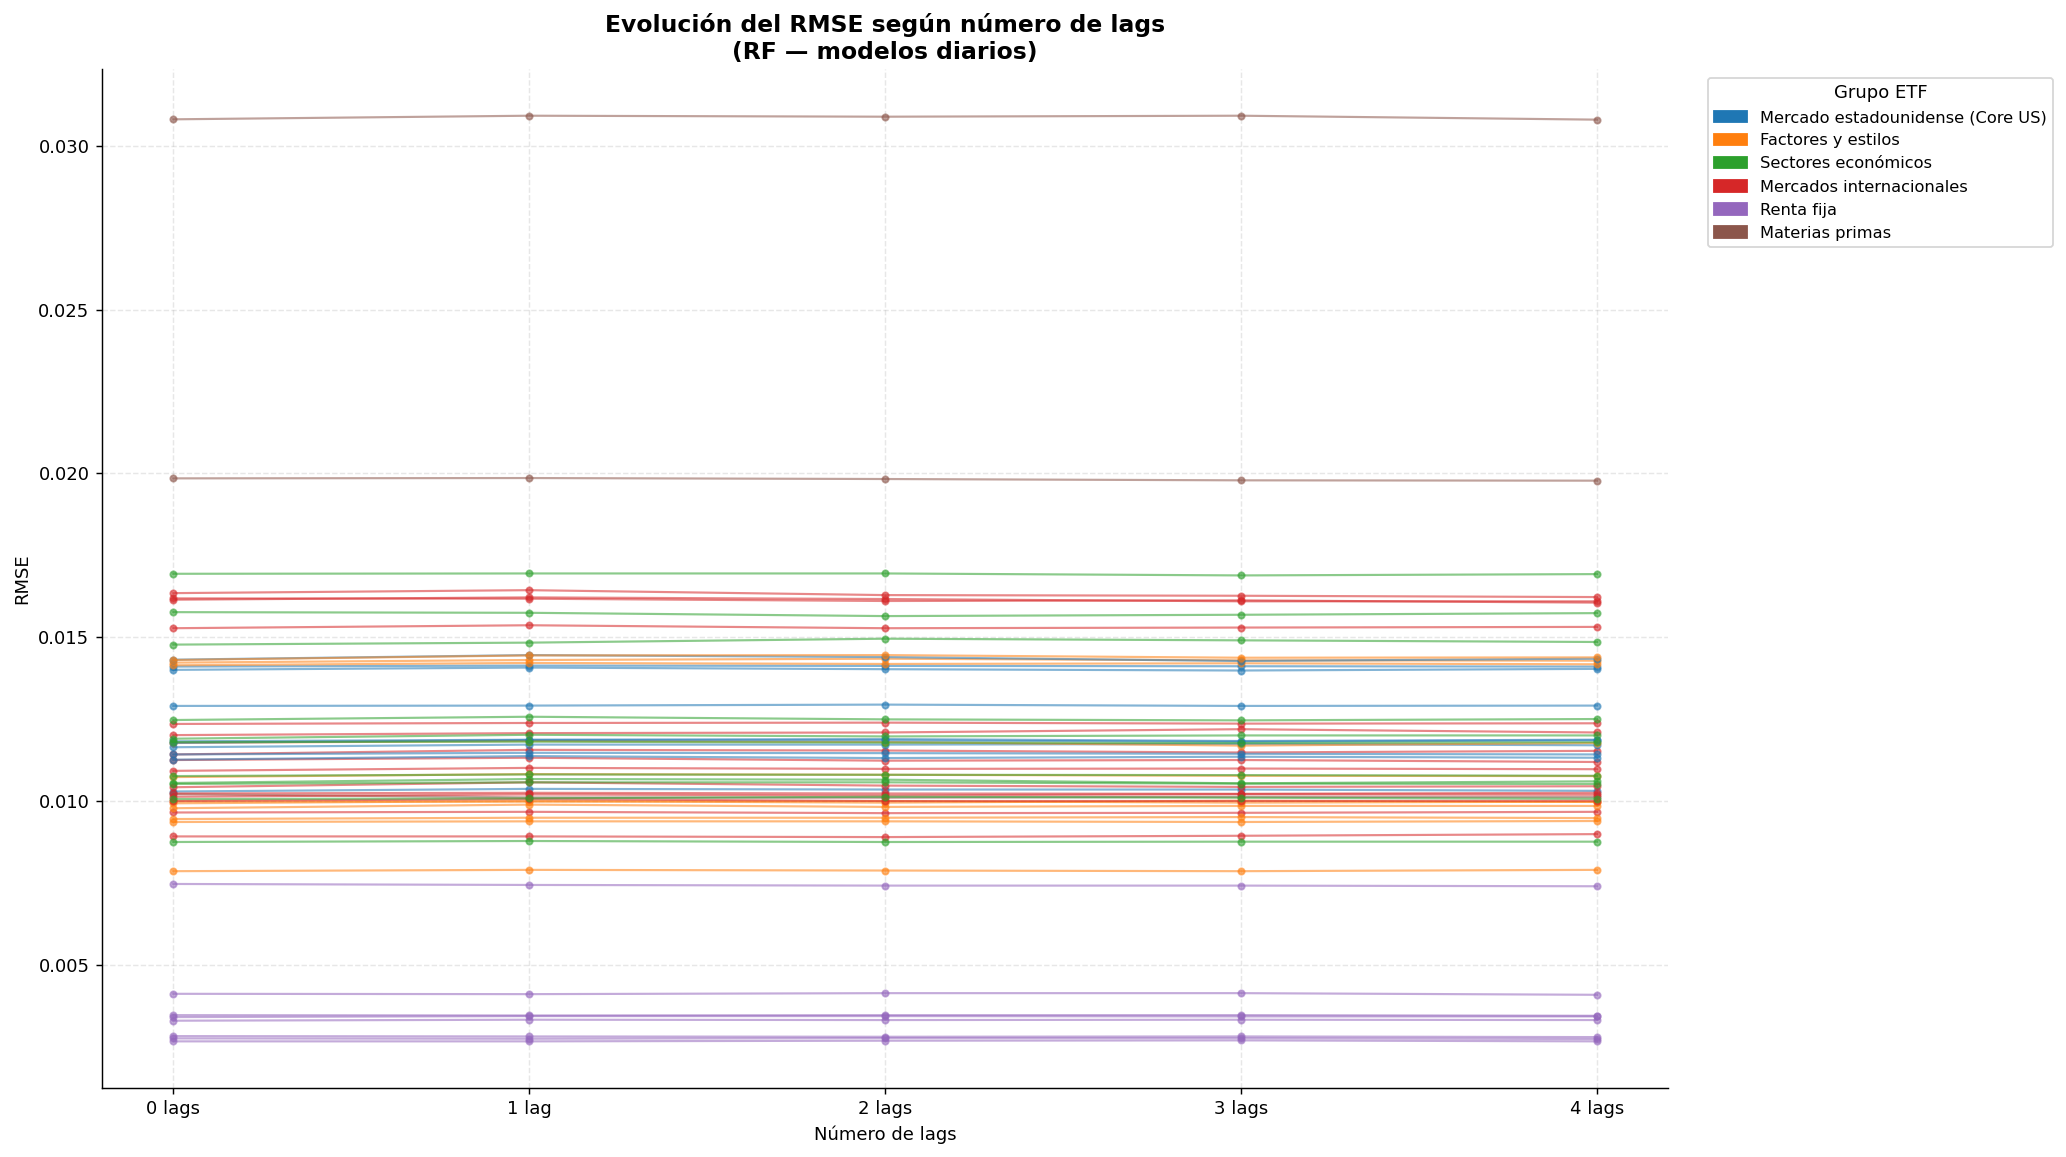

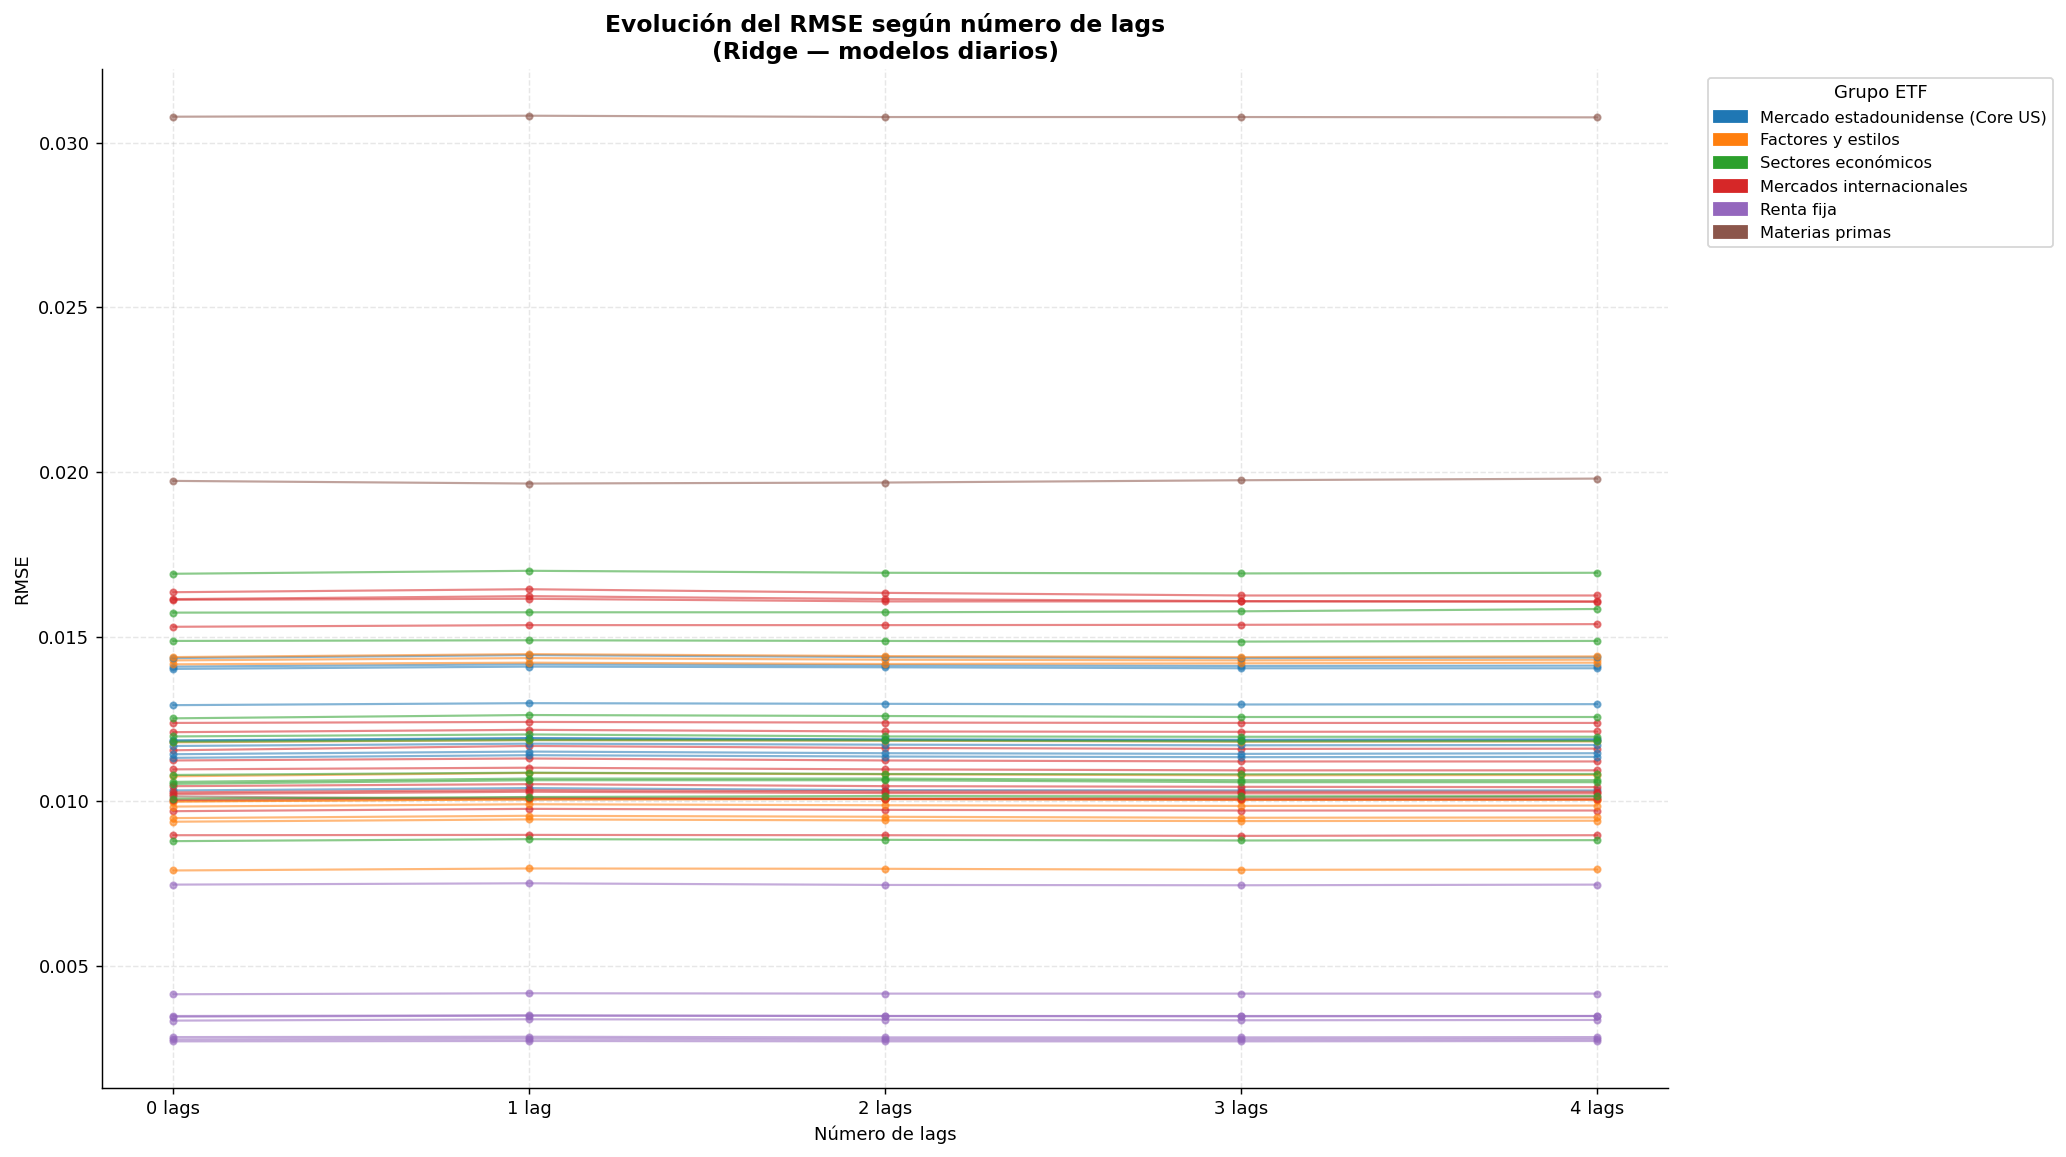

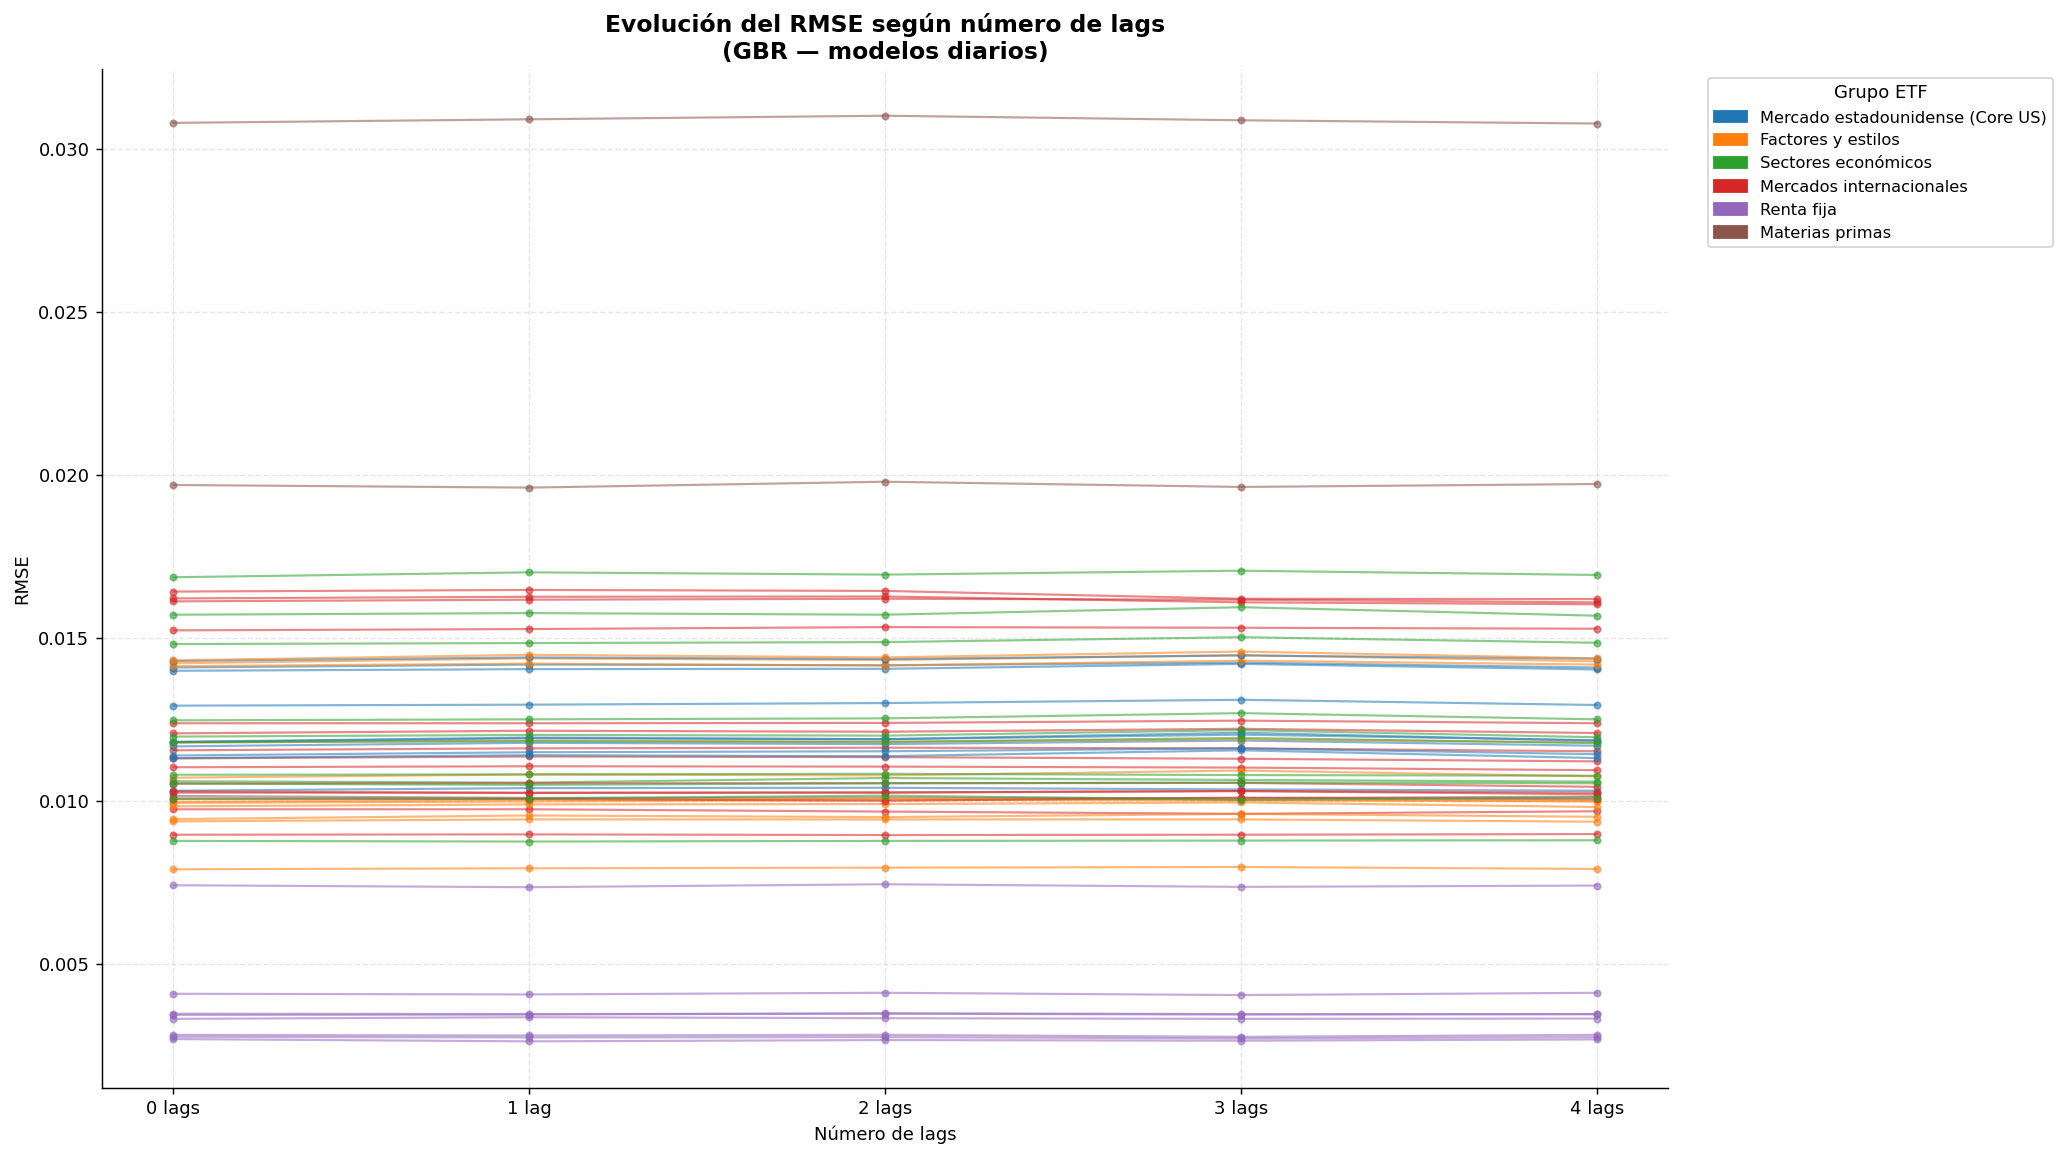

In [18]:
import matplotlib.patches as mpatches
archivos_ev = ["df_diario.csv","df_diario_1.csv","df_diario_2.csv","df_diario_3.csv","df_diario_4.csv"]
COLORES_GR2 = {
    "Mercado estadounidense (Core US)":"#1f77b4",
    "Factores y estilos":"#ff7f0e",
    "Sectores económicos":"#2ca02c",
    "Mercados internacionales":"#d62728",
    "Renta fija":"#9467bd",
    "Materias primas":"#8c564b",
    "Sin grupo":"#7f7f7f"
}
df_ev2=df.copy()
df_ev2["RMSE"]=pd.to_numeric(df_ev2["RMSE"],errors="coerce")
df_ev2["Grupo"]=df_ev2["ETF"].map(etf_to_grupo).fillna("Sin grupo")
df_ev2=df_ev2[~df_ev2["ETF"].isin(ETF_ELIMINADOS)].copy()
nc=lambda m: m.replace("GradientBoostingRegressor","GBR").replace("RandomForestRegressor","RF").replace("LinearRegression","LR")
mejor_rmse=df_ev2.groupby("Método")["RMSE"].mean().idxmin()
for met in list(dict.fromkeys([mejor_rmse,"Ridge","RandomForestRegressor","GradientBoostingRegressor"])):
    sub=df_ev2[df_ev2["Método"]==met].copy()
    if sub.empty: continue
    fig,ax=plt.subplots(figsize=(16,9))
    for etf in sorted(sub["ETF"].dropna().unique()):
        se=sub[sub["ETF"]==etf].set_index("Archivo").reindex(archivos_ev)
        g=sub.loc[sub["ETF"]==etf,"Grupo"].iloc[0]
        ax.plot([LAGS_LABEL.get(a,a) for a in archivos_ev],se["RMSE"].values,
                marker="o",linestyle="-",linewidth=1.2,markersize=3.5,alpha=0.55,color=COLORES_GR2.get(g,"#888888"))
    patches=[mpatches.Patch(color=COLORES_GR2[g],label=g) for g in ORDEN_GRUPOS if g in sub["Grupo"].unique()]
    ax.legend(handles=patches,title="Grupo ETF",fontsize=9,title_fontsize=10,loc="upper left",bbox_to_anchor=(1.02,1))
    ax.set_title(f"Evolución del RMSE según número de lags\n({nc(met)} — modelos diarios)",fontsize=13,fontweight="bold")
    ax.set_xlabel("Número de lags"); ax.set_ylabel("RMSE"); ax.grid(True,alpha=0.3)
    plt.tight_layout(); plt.show()

Las líneas de cada ETF son casi planas de izquierda a derecha: el RMSE apenas cambia al pasar de 0 a 4 lags. Esto confirma una vez más que añadir más semanas de histórico no mejora las predicciones.

Los ETFs de materias primas (líneas marrones) aparecen en la parte alta del gráfico porque tienen más volatilidad, no porque el modelo funcione peor con ellos en términos relativos. Los de renta fija (líneas moradas) están abajo porque sus retornos son más pequeños en magnitud.

Si hubiera algún ETF con una línea con pendiente negativa clara (que bajara de izquierda a derecha), significaría que ese activo tiene memoria diarios que el modelo puede aprovechar. En general eso no ocurre de forma sistemática.